# Machine Learning Classification of Congenital Heart Disease Subtypes (VSD, ASD, PDA)

**Objective:** Build and compare supervised classification models (Logistic Regression, Decision Tree, Random Forest, XGBoost) to distinguish three common congenital heart disease subtypes — Ventricular Septal Defect (VSD), Atrial Septal Defect (ASD), and Patent Ductus Arteriosus (PDA) — from clinical patient records.

**Dataset:** 350 patient records from a paediatric cardiology registry.  
**Target variable:** ICD-10 coded CHD diagnosis mapped to VSD / ASD / PDA.


## 1. Libraries and Configuration

In [1]:
!pip -q install shap lime
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              roc_auc_score, accuracy_score,
                              precision_recall_fscore_support)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTENC
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

# ── Configuration — change this path to point to your copy of the CSV ──
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Dataset/DB1_cleaned_SOPLO.csv"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Dataset

The raw dataset contains 94 columns. We begin by loading it, inspecting its shape, and noting which columns carry missing values.


In [3]:
dfRaw = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape: {dfRaw.shape}")
print(f"Duplicate rows   : {dfRaw.duplicated().sum()}")
print("\nMissing values per selected column:")
selected_raw = ['2.SEXO','EDAD 1era cita','6. PESO (KG)','7. TALLA (CM)',
                '8. P/A','9. FC','10. SaO2','11. Sx Prin',
                'Otros Sxs','11. (b) SOPLO','5.a CLAS CC']
print(dfRaw[selected_raw].isnull().sum())


Raw dataset shape: (350, 60)
Duplicate rows   : 0

Missing values per selected column:
2.SEXO              2
EDAD 1era cita      2
6. PESO (KG)        2
7. TALLA (CM)      11
8. P/A              2
9. FC               2
10. SaO2            2
11. Sx Prin         2
Otros Sxs         303
11. (b) SOPLO       2
5.a CLAS CC         2
dtype: int64


## 3. Feature Selection and Column Renaming

We retain only the clinically relevant features identified in the research design: demographics (sex, age, weight, height), vitals (blood pressure, heart rate, oxygen saturation), symptoms, and cardiac murmur description.


In [4]:
selected_features = [
    '2.SEXO', 'EDAD 1era cita', '6. PESO (KG)', '7. TALLA (CM)',
    '8. P/A', '9. FC', '10. SaO2',
    '11. Sx Prin', 'Otros Sxs', '11. (b) SOPLO'
]
target_column = '5.a CLAS CC'

df = dfRaw[selected_features + [target_column]].copy()

column_rename = {
    '2.SEXO':        'Gender',
    'EDAD 1era cita':'Age at First Visit',
    '6. PESO (KG)':  'Weight (KG)',
    '7. TALLA (CM)': 'Height (CM)',
    '8. P/A':        'Blood Pressure',
    '9. FC':         'Heart Rate',
    '10. SaO2':      'Arterial Oxygen Saturation',
    '11. Sx Prin':   'Primary Symptom',
    'Otros Sxs':     'Secondary Symptoms',
    '11. (b) SOPLO': 'Cardiac Murmur Description',
    '5.a CLAS CC':   'CHD Classification'
}
df = df.rename(columns=column_rename)

# Standardise NR / N/A / blank → NaN
df = df.replace(['NR', 'N/A', '', ' '], np.nan)

print("Shape after feature selection:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())


Shape after feature selection: (350, 11)

Missing values:
Gender                          2
Age at First Visit              7
Weight (KG)                    10
Height (CM)                    11
Blood Pressure                 74
Heart Rate                     15
Arterial Oxygen Saturation     15
Primary Symptom                 4
Secondary Symptoms            303
Cardiac Murmur Description      2
CHD Classification              2
dtype: int64


## 4. Target Column: Map ICD-10 Codes to Class Labels

The raw target contains 30+ ICD-10 codes. We map the three classes of interest and drop all other rows.

| ICD-10 | Label |
|--------|-------|
| Q21.0  | VSD   |
| Q21.1  | ASD   |
| Q25.0  | PDA   |


In [5]:
icd_map = {'Q21.0': 'VSD', 'Q21.1': 'ASD', 'Q25.0': 'PDA'}
df['CHD Classification'] = df['CHD Classification'].map(icd_map)
df = df[df['CHD Classification'].notna()].copy()
df = df.reset_index(drop=True)

print("Dataset after filtering — shape:", df.shape)
print("\nClass distribution:")
print(df['CHD Classification'].value_counts())


Dataset after filtering — shape: (208, 11)

Class distribution:
CHD Classification
VSD    93
ASD    69
PDA    46
Name: count, dtype: int64


## 5. Age Conversion (String → Months)

Age is recorded as mixed strings such as `14a` (years), `3m` (months), `15dias` (days). We use strict regular expressions to parse each format safely and convert everything to months.


In [6]:
def convert_age_to_months(s):
    """Convert age strings like '14a', '3m', '15dias' to float (months)."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    # days
    m = re.fullmatch(r'(\d+\.?\d*)\s*dias?', s)
    if m:
        return float(m.group(1)) / 30.437
    # years
    m = re.fullmatch(r'(\d+\.?\d*)\s*a', s)
    if m:
        return float(m.group(1)) * 12
    # months
    m = re.fullmatch(r'(\d+\.?\d*)\s*m', s)
    if m:
        return float(m.group(1))
    return np.nan

df['Age at First Visit (months)'] = df['Age at First Visit'].apply(convert_age_to_months)
df = df.drop(columns=['Age at First Visit'])

print("Age conversion — null count:", df['Age at First Visit (months)'].isnull().sum())
print("Age range (months):", df['Age at First Visit (months)'].min(),
      "–", df['Age at First Visit (months)'].max())


Age conversion — null count: 4
Age range (months): 0.13141899661596082 – 204.0


## 6. Blood Pressure: Split into Systolic and Diastolic

Blood pressure is stored as `"120/80"`. We split on `/` and create two separate numeric columns.


In [7]:
# Fill missing BP with mode before splitting
bp_mode = df['Blood Pressure'].mode()[0]
df['Blood Pressure'] = df['Blood Pressure'].fillna(bp_mode)

bp_split = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic BP']  = pd.to_numeric(bp_split[0], errors='coerce')
df['Diastolic BP'] = pd.to_numeric(bp_split[1], errors='coerce')
df = df.drop(columns=['Blood Pressure'])

print("Null values after BP split:")
print(df[['Systolic BP','Diastolic BP']].isnull().sum())


Null values after BP split:
Systolic BP     0
Diastolic BP    0
dtype: int64


## 7. Cardiac Murmur Description Parsing

The free-text murmur field encodes three pieces of information: murmur **type** (e.g. SS, SHS, S-D), **grade** (e.g. GII, G3), and **auscultation zone** (e.g. FOCO PULMONAR, BPEI). We extract each with regular expressions.


### Type processing

In [8]:
df_CMD = df.copy()

df_CMD['Cardiac Murmur Type'] = df_CMD['Cardiac Murmur Description']
print(df_CMD.head())


def typeProcessing(CMtype):
    if pd.isna(CMtype):
        return np.nan

    if 'SS' in CMtype:
        try:
            return 'SS'
        except ValueError:
            pass
    elif 'SHS' in CMtype:
        try:
            return 'SHS'
        except ValueError:
            pass
    elif 'S-D' in CMtype:
        try:
            return 'S-D'
        except ValueError:
            pass
    elif 'S CONTINUO' in CMtype:
      try:
        return 'S CONTINUO'
      except ValueError:
        pass
    elif 'S EYECTIVO' in CMtype:
      try:
        return 'S EYECTIVO'
      except ValueError:
        pass
    else:
      try:
        return 'NO'
      except ValueError:
        pass

    return CMtype


df_CMD['Cardiac Murmur Type'] = df_CMD['Cardiac Murmur Type'].apply(typeProcessing)

print("\nUnique values in 'Cardiac Murmur Type':")
for value in df_CMD['Cardiac Murmur Type'].unique():
    print(value)


def removeTypeProcessing(CMtype):
    if pd.isna(CMtype):
        return np.nan

    if 'SS' in CMtype:
        try:
            return CMtype.replace('SS', '').strip()
        except ValueError:
            pass
    elif 'SHS' in CMtype:
        try:
            return CMtype.replace('SHS', '').strip()
        except ValueError:
            pass
    elif 'S-D' in CMtype:
        try:
            return CMtype.replace('S-D', '').strip()
        except ValueError:
            pass
    elif 'S CONTINUO' in CMtype:
      try:
        return CMtype.replace('S CONTINUO', '').strip()
      except ValueError:
        pass
    elif 'S EYECTIVO' in CMtype:
      try:
        return CMtype.replace('S EYECTIVO', '').strip()
      except ValueError:
        pass

    return CMtype


df_CMD['Cardiac Murmur Description'] = df_CMD['Cardiac Murmur Description'].apply(removeTypeProcessing)
print("\nUnique values in 'Cardiac Murmur Description':")
for value in df_CMD['Cardiac Murmur Description'].unique():
    print(value)


      Gender Weight (KG)  Height (CM) Heart Rate Arterial Oxygen Saturation  \
0   FEMENINO        50.2        173.2         77                         99   
1  MASCULINO        31.6        143.0         80                         99   
2   FEMENINO        15.6         95.5        117                        100   
3  MASCULINO           4         60.0        127                         94   
4   FEMENINO        21.5        117.4        101                         98   

  Primary Symptom Secondary Symptoms        Cardiac Murmur Description  \
0             asx                asx           SHS G4 FOCO TRICUSPIDEO   
1             asx                asx           SHS G2 FOCO TRICUSPIDEO   
2             asx                asx                                NO   
3       Taquipnea                asx  SS G5 EN BPEI BAJO IIP REFORZADO   
4             asx                asx                                NO   

  CHD Classification  Age at First Visit (months)  Systolic BP  Diastolic BP  \


### Grade processing

In [9]:
df_CMD['Cardiac Murmur Grade'] = df_CMD['Cardiac Murmur Description']


def gradeProcessing(CMgrade):
    if pd.isna(CMgrade):
        return np.nan

    if 'G1-2' in CMgrade:
        try:
            return 'G1-2'
        except ValueError:
            pass

    elif 'G2-3' in CMgrade:
        try:
            return 'G2-3'
        except ValueError:
            pass

    elif 'G4-5' in CMgrade:
        try:
            return 'G4-5'
        except ValueError:
            pass

    elif 'G1' in CMgrade:
        try:
            return 'G1'
        except ValueError:
            pass

    elif 'G2' in CMgrade:
        try:
            return 'G2'
        except ValueError:
            pass

    elif 'G3' in CMgrade:
        try:
            return 'G3'
        except ValueError:
            pass

    elif 'G4' in CMgrade:
        try:
            return 'G4'
        except ValueError:
            pass

    elif 'G5' in CMgrade:
        try:
            return 'G5'
        except ValueError:
            pass
    else:
      return 'NO'

    return CMgrade


df_CMD['Cardiac Murmur Grade'] = df_CMD['Cardiac Murmur Grade'].apply(gradeProcessing)

print("\nUnique values in 'Cardiac Murmur Grade':")
for value in df_CMD['Cardiac Murmur Grade'].unique():
    print(value)


def removeGradeProcessing(CMgrade):
    if pd.isna(CMgrade):
        return np.nan

    if 'G1-2' in CMgrade:
        try:
            return CMgrade.replace('G1-2', '').strip()
        except ValueError:
            pass

    elif 'G2-3' in CMgrade:
        try:
            return CMgrade.replace('G2-3', '').strip()
        except ValueError:
            pass

    elif 'G4-5' in CMgrade:
        try:
            return CMgrade.replace('G4-5', '').strip()
        except ValueError:
            pass

    elif 'G1' in CMgrade:
        try:
            return CMgrade.replace('G1', '').strip()
        except ValueError:
            pass

    elif 'G2' in CMgrade:
        try:
            return CMgrade.replace('G2', '').strip()
        except ValueError:
            pass

    elif 'G3' in CMgrade:
        try:
            return CMgrade.replace('G3', '').strip()
        except ValueError:
            pass

    elif 'G4' in CMgrade:
        try:
            return CMgrade.replace('G4', '').strip()
        except ValueError:
            pass

    elif 'G5' in CMgrade:
        try:
            return CMgrade.replace('G5', '').strip()
        except ValueError:
            pass

    return CMgrade


df_CMD['Cardiac Murmur Description'] = df_CMD['Cardiac Murmur Description'].apply(removeGradeProcessing)

print("\nUnique values in 'Cardiac Murmur Description':")
for value in df_CMD['Cardiac Murmur Description'].unique():
    print(value)



Unique values in 'Cardiac Murmur Grade':
G4
G2
NO
G5
G3
G2-3
G1
G1-2
G4-5

Unique values in 'Cardiac Murmur Description':
FOCO TRICUSPIDEO
NO
EN BPEI BAJO IIP REFORZADO
FOCO AORTICO
FOCO PULMONAR, R2 DESDOBLADO CONSTANTE Y FIJO
EN BPEI
FOCO PULMONAR

EN 4TO EII
, IIR INTENSO
EN BPEI IRRADIADO EN BARRA
, R2 DESDOBLADO CONSTANTE
EN BPEI, MUSICAL, VIBRATORIO
BPEI
TRICUSPIDEO
EN BPEI BAJO
VIBRATORIO
FOCO PULMONAR, IIP DESDOBLADO
EIC 3-4, BPEI
CORTO 3ER EIC BPEI
FOCO PULMONAR R2 DESDOBLADO
2DO EIC IIP DESDOBLADO
4TO EII
TODO BPEI
EN BPEI ALTO
BPEI ALTO
EN 2DO EII
MITRAL
PREDOMINANTE MITRAL
R2 DESDOBLADO CONSTANTE EN FOCO PULMONAR
BPEI BAJO, IIP REFORZADO
EN BPEI ALTO, IIP DESDOBLADO
BPEI BAJO
CORTO, APICAL
CORTO EN 4TO EIC, RITMO IRREGULAR CON PRESENCIA DE EXTRASISTOLES
3ER E II
BPEI BAJO, RUGOSO EN FOCO PULMONAR
CORTO  EN BPEI
BPIM
R2 DESDOBLADO FIJO Y PERMANENTE,   EN FOCO PULMONAR
EN BPIB
REGION INFRACLAVICULAR
DESDOBLAMIENTO DEL 2P
EN BPIM
IRRADIADO EN BARRA EN BPIM
BPIM IRRADIADO EN B

### Location processing

In [10]:
# print("\nUnique values in 'Cardiac Murmur Description':")
# for value in df_CMD['Cardiac Murmur Description'].unique():
#     print(value)

def locProcessing(CMgrade):
    if pd.isna(CMgrade):
        return np.nan

    elif 'FOCO PULMONAR' in CMgrade:
        try:
            return 'FOCO PULMONAR'
        except ValueError:
            pass

    elif 'FOCO TRICUSPIDEO' in CMgrade:
        try:
            return 'FOCO TRICUSPIDEO'
        except ValueError:
            pass

    elif 'BPIA' in CMgrade:
        try:
            return 'BPIA'
        except ValueError:
            pass

    elif 'BPIM' in CMgrade:
        try:
            return 'BPIM'
        except ValueError:
            pass

    elif 'BPEI ALTO' in CMgrade:
        try:
            return 'BPEI ALTO'
        except ValueError:
            pass

    elif 'BPEI BAJO' in CMgrade:
        try:
            return 'BPEI BAJO'
        except ValueError:
            pass

    elif 'BPEI' in CMgrade and 'BAJO' not in CMgrade and 'ALTO' not in CMgrade:
        try:
            return 'BPEI'
        except ValueError:
            pass

    elif 'EN' in CMgrade[:3]:
        try:
            return CMgrade.replace(CMgrade[:3], '').strip()
        except ValueError:
            pass

    elif ',' in CMgrade[:3]:
        try:
            return CMgrade.replace(',', '').strip()
        except ValueError:
            pass

    return CMgrade

df_CMD['Cardiac Murmur Description'] = df_CMD['Cardiac Murmur Description'].apply(locProcessing)
print(df_CMD['Cardiac Murmur Description'].value_counts())
df_CMD.rename(columns={'Cardiac Murmur Description': 'Cardiac Murmur Zone'}, inplace=True)




Cardiac Murmur Description
BPEI                                                                         55
NO                                                                           33
FOCO PULMONAR                                                                29
                                                                             15
BPIM                                                                         11
FOCO TRICUSPIDEO                                                             10
BPEI ALTO                                                                     9
BPEI BAJO                                                                     6
2DO EII                                                                       5
BPIA                                                                          5
FOCO AORTICO                                                                  4
4TO EII                                                                       4
BPIB         

In [11]:
column_rename = {
    'Cardiac Murmur Type':  'Murmur Type',
    'Cardiac Murmur Grade': 'Murmur Grade',
    'Cardiac Murmur Zone':  'Murmur Zone'
}
df_CMD = df_CMD.rename(columns=column_rename)
df = df_CMD.copy()
print(df.head())

# Standardise NR / N/A / blank → NaN
print(df.isnull().sum())
df = df.replace(['', ' '], np.nan)
print(df.isnull().sum())

print("Murmur Type  distribution:\n", df['Murmur Type'].value_counts())
print("\nMurmur Grade distribution:\n", df['Murmur Grade'].value_counts())
print("\nMurmur Zone  distribution:\n", df['Murmur Zone'].value_counts())

      Gender Weight (KG)  Height (CM) Heart Rate Arterial Oxygen Saturation  \
0   FEMENINO        50.2        173.2         77                         99   
1  MASCULINO        31.6        143.0         80                         99   
2   FEMENINO        15.6         95.5        117                        100   
3  MASCULINO           4         60.0        127                         94   
4   FEMENINO        21.5        117.4        101                         98   

  Primary Symptom Secondary Symptoms       Murmur Zone CHD Classification  \
0             asx                asx  FOCO TRICUSPIDEO                VSD   
1             asx                asx  FOCO TRICUSPIDEO                VSD   
2             asx                asx                NO                PDA   
3       Taquipnea                asx         BPEI BAJO                VSD   
4             asx                asx                NO                PDA   

   Age at First Visit (months)  Systolic BP  Diastolic BP Murm

## 8. Symptom Standardisation

`asx` is a local abbreviation for *asymptomatic*. We normalise it and fill missing secondary symptoms from the primary symptom column.


In [12]:
def clean_symptom(s):
    if pd.isna(s): return np.nan
    if str(s).strip().lower() == 'asx': return 'Asymptomatic'
    return str(s).strip()

df['Primary Symptom']   = df['Primary Symptom'].apply(clean_symptom)
df['Secondary Symptoms'] = df['Secondary Symptoms'].apply(clean_symptom)

# Fill missing secondary symptom with primary
df['Secondary Symptoms'] = df['Secondary Symptoms'].fillna(df['Primary Symptom'])

print("Null after symptom cleaning:")
print(df[['Primary Symptom','Secondary Symptoms']].isnull().sum())


Null after symptom cleaning:
Primary Symptom       0
Secondary Symptoms    0
dtype: int64


## 9. Missing Value Imputation

| Column | Strategy | Justification |
|--------|----------|---------------|
| Weight, Height | Mean | Continuous, approximately normal in paediatric ranges |
| Age, Heart Rate, SaO2, BP | Median | Continuous but potentially skewed; median is robust to outliers |
| Gender, Primary/Secondary Symptom | Mode | Categorical; replace with most common category |
| Murmur fields | Mode | Categorical |


In [13]:
# Numeric — median
for col in ['Age at First Visit (months)', 'Heart Rate',
            'Arterial Oxygen Saturation', 'Systolic BP', 'Diastolic BP']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Numeric — mean
for col in ['Weight (KG)', 'Height (CM)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

# Categorical — mode
for col in ['Gender', 'Primary Symptom', 'Secondary Symptoms',
            'Murmur Type', 'Murmur Grade', 'Murmur Zone']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Null values after imputation:")
print(df.isnull().sum())
print("\nFinal preprocessed shape:", df.shape)


Null values after imputation:
Gender                         0
Weight (KG)                    0
Height (CM)                    0
Heart Rate                     0
Arterial Oxygen Saturation     0
Primary Symptom                0
Secondary Symptoms             0
Murmur Zone                    0
CHD Classification             0
Age at First Visit (months)    0
Systolic BP                    0
Diastolic BP                   0
Murmur Type                    0
Murmur Grade                   0
dtype: int64

Final preprocessed shape: (208, 14)


## 10. Exploratory Data Analysis

Before modelling we examine the class distribution, numeric feature distributions per class, and correlations.


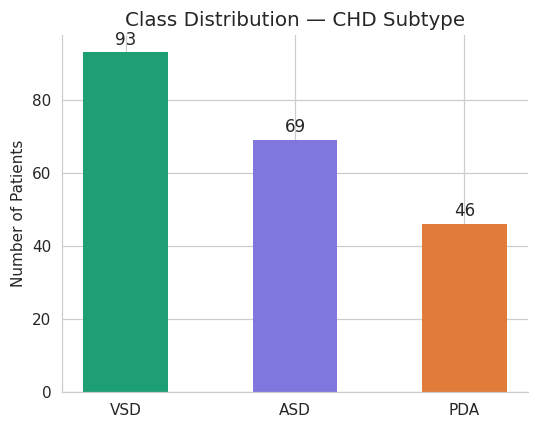

In [14]:
TARGET = 'CHD Classification'

# ── 10.1  Class distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#1D9E75','#7F77DD','#E07B39'], edgecolor='none', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, str(val),
            ha='center', va='bottom', fontsize=11)
ax.set_title("Class Distribution — CHD Subtype", fontsize=13)
ax.set_ylabel("Number of Patients")
ax.set_xlabel("")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


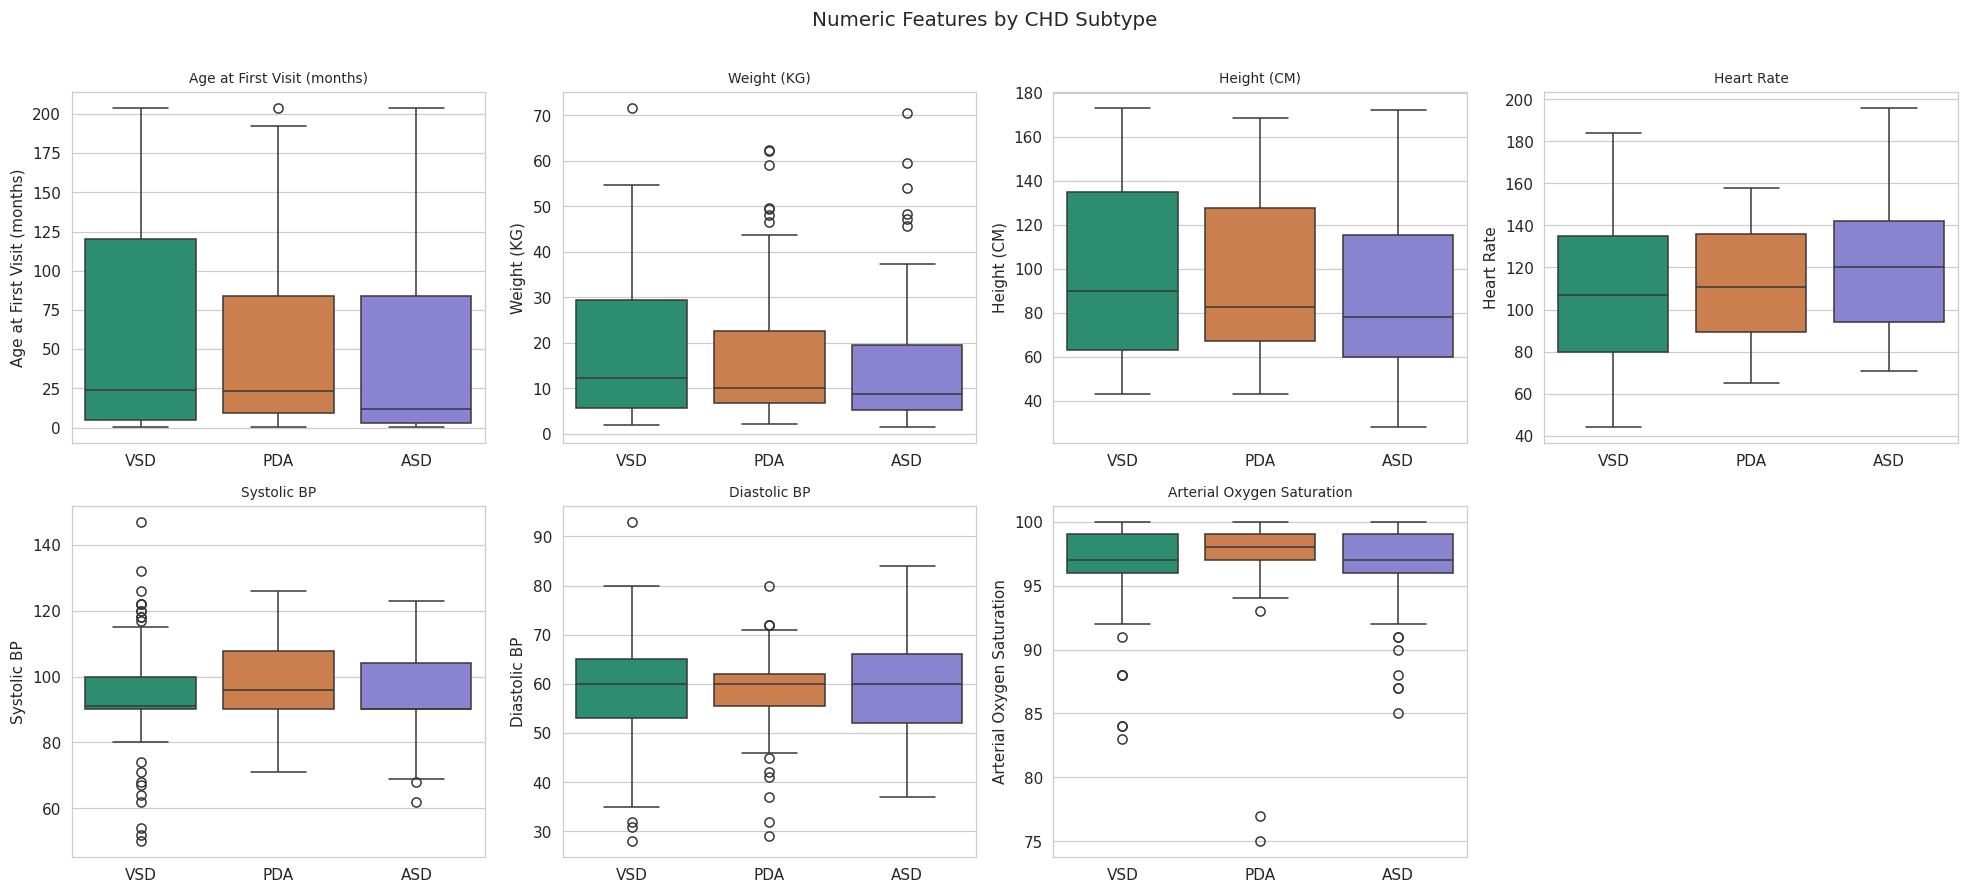

In [15]:
# ── 10.2  Numeric feature distributions by class ─────────────────────────
numeric_cols = ['Age at First Visit (months)', 'Weight (KG)', 'Height (CM)',
                'Heart Rate', 'Systolic BP', 'Diastolic BP',
                'Arterial Oxygen Saturation']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
palette = {'VSD':'#1D9E75', 'ASD':'#7F77DD', 'PDA':'#E07B39'}
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET,
                palette=palette, legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
axes[-1].axis('off')
plt.suptitle("Numeric Features by CHD Subtype", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


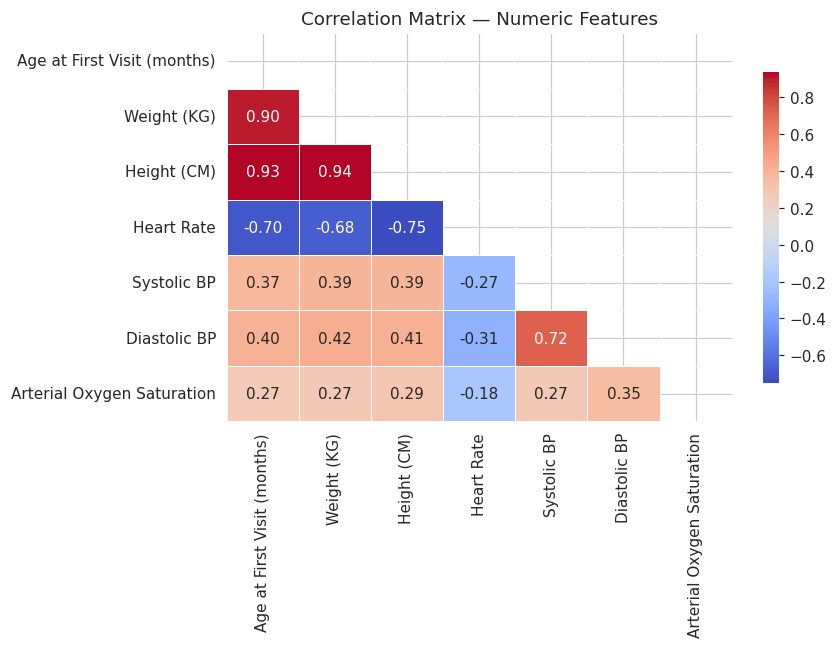

In [16]:
# ── 10.3  Correlation heatmap (numeric features only) ────────────────────
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title("Correlation Matrix — Numeric Features", fontsize=12)
plt.tight_layout()
plt.show()


## 11. Feature Encoding

- **Gender**: Binary label encoding (0/1).
- **Primary Symptom, Murmur Type**: One-hot encoding (all categories retained; sparse columns collapsed into `_Other`).
- **Secondary Symptoms, Murmur Zone**: Top-N one-hot with an `_Other` bucket.
- **Murmur Grade**: Ordinal integer encoding (NONE < G1 < G1-2 < G2 < … < G5).

All encoders are fitted **only on training data** to prevent data leakage.


In [17]:
# ── Separate features and target BEFORE any encoding ─────────────────────
X_raw = df.drop(columns=[TARGET]).copy()
le_target = LabelEncoder()
y = le_target.fit_transform(df[TARGET])
class_names = le_target.classes_
print("Class encoding:", dict(zip(le_target.classes_,
                                   le_target.transform(le_target.classes_))))

# ── Train / test split (stratified) ──────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train_raw.shape[0]} rows | Test: {X_test_raw.shape[0]} rows")
print("Train class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))




Class encoding: {'ASD': np.int64(0), 'PDA': np.int64(1), 'VSD': np.int64(2)}

Train: 166 rows | Test: 42 rows
Train class counts: [55 37 74]
Test  class counts: [14  9 19]


In [18]:
# ── Helper: top-N one-hot with Other bucket ───────────────────────────────
def topn_ohe(train_series, test_series, n, prefix):
    top = train_series.value_counts().nlargest(n).index.tolist()
    def encode(s):
        rows = []
        for val in s:
            row = {f'{prefix}_{c}': int(val == c) for c in top}
            row[f'{prefix}_Other'] = int(val not in top)
            rows.append(row)
        return pd.DataFrame(rows, index=s.index)
    return encode(train_series), encode(test_series)

def encode_split(X_tr, X_te):
    tr, te = X_tr.copy(), X_te.copy()

    # 1. Gender — binary
    g_map = {'FEMENINO': 0, 'MASCULINO': 1}
    tr['Gender'] = tr['Gender'].map(g_map).fillna(0).astype(int)
    te['Gender'] = te['Gender'].map(g_map).fillna(0).astype(int)

    # 2. Murmur Grade — ordinal
    grade_order = ['NO','G1','G1-2','G2','G2-3','G3','G4','G4-5','G5']
    grade_map   = {g: i for i, g in enumerate(grade_order)}
    tr['Murmur Grade'] = tr['Murmur Grade'].map(grade_map).fillna(0).astype(int)
    te['Murmur Grade'] = te['Murmur Grade'].map(grade_map).fillna(0).astype(int)

    # 3. Primary Symptom — full OHE (fit on train)
    ps_cats = tr['Primary Symptom'].value_counts().index.tolist()
    tr_ps, te_ps = topn_ohe(tr['Primary Symptom'], te['Primary Symptom'],
                             len(ps_cats), 'PrimarySx')
    tr = pd.concat([tr.drop(columns=['Primary Symptom']), tr_ps], axis=1)
    te = pd.concat([te.drop(columns=['Primary Symptom']), te_ps], axis=1)

    # 4. Secondary Symptoms — top 8 + Other
    tr_ss, te_ss = topn_ohe(tr['Secondary Symptoms'], te['Secondary Symptoms'],
                             8, 'SecondarySx')
    tr = pd.concat([tr.drop(columns=['Secondary Symptoms']), tr_ss], axis=1)
    te = pd.concat([te.drop(columns=['Secondary Symptoms']), te_ss], axis=1)

    # 5. Murmur Type — full OHE
    mt_cats = tr['Murmur Type'].value_counts().index.tolist()
    tr_mt, te_mt = topn_ohe(tr['Murmur Type'], te['Murmur Type'],
                             len(mt_cats), 'MurmurType')
    tr = pd.concat([tr.drop(columns=['Murmur Type']), tr_mt], axis=1)
    te = pd.concat([te.drop(columns=['Murmur Type']), te_mt], axis=1)

    # 6. Murmur Zone — top 11 + Other
    tr_mz, te_mz = topn_ohe(tr['Murmur Zone'], te['Murmur Zone'],
                             11, 'MurmurZone')
    tr = pd.concat([tr.drop(columns=['Murmur Zone']), tr_mz], axis=1)
    te = pd.concat([te.drop(columns=['Murmur Zone']), te_mz], axis=1)

    # Align columns (test may miss rare OHE cols)
    tr, te = tr.align(te, join='left', axis=1, fill_value=0)
    return tr, te

X_train_enc, X_test_enc = encode_split(X_train_raw, X_test_raw)
print("Encoded feature matrix — train:", X_train_enc.shape)
print("Encoded feature matrix — test :", X_test_enc.shape)


Encoded feature matrix — train: (166, 46)
Encoded feature matrix — test : (42, 46)


## 12. Class Imbalance Handling — SMOTENC

The dataset has 93 VSD, 69 ASD, and 46 PDA cases — a moderate imbalance. We apply **SMOTENC** (SMOTE for mixed numeric/categorical data) to the **training set only**, oversampling minority classes to equal counts. The test set is never touched.


In [19]:
# All columns after encoding are numeric (OHE columns are 0/1)
# SMOTENC requires identifying categorical column indices
# After encoding, all features are effectively numeric → use standard SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_enc, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After  SMOTE:", np.bincount(y_train_bal))
print("Training set size after SMOTE:", X_train_bal.shape)


Before SMOTE: [55 37 74]
After  SMOTE: [74 74 74]
Training set size after SMOTE: (222, 46)


## 13. Model Training

We train four classifiers and evaluate each on the held-out test set. Cross-validation (5-fold, stratified) is reported alongside test metrics to check for overfitting.


In [20]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, model, X_tr, y_tr, X_te, y_te, scale=False):
    """Fit, predict, and return a summary dict."""
    if scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_te, y_pred, target_names=class_names))
    auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
    print(f"Macro ROC-AUC (OvR): {auc:.3f}")
    cv = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='f1_macro')
    print(f"5-fold CV macro-F1 : {cv.mean():.3f} ± {cv.std():.3f}")
    acc   = accuracy_score(y_te, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='macro',
                                                   zero_division=0)
    return {
        'Model': name, 'y_pred': y_pred, 'y_proba': y_proba,
        'fitted_model': model,
        'Accuracy': acc, 'Precision (macro)': p,
        'Recall (macro)': r, 'F1 (macro)': f1,
        'ROC-AUC': auc, 'CV F1 mean': cv.mean(), 'CV F1 std': cv.std(), 'scaler': scaler
    }


In [21]:
# ── Logistic Regression ───────────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=3000, class_weight='balanced',
                               random_state=RANDOM_STATE)
lr_res = evaluate('Logistic Regression', lr_model,
                  X_train_bal, y_train_bal, X_test_enc, y_test, scale=True)



  Logistic Regression
              precision    recall  f1-score   support

         ASD       0.85      0.79      0.81        14
         PDA       0.73      0.89      0.80         9
         VSD       0.94      0.89      0.92        19

    accuracy                           0.86        42
   macro avg       0.84      0.86      0.84        42
weighted avg       0.87      0.86      0.86        42

Macro ROC-AUC (OvR): 0.947
5-fold CV macro-F1 : 0.674 ± 0.033


In [22]:
# ── Decision Tree ─────────────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                                   class_weight='balanced',
                                   random_state=RANDOM_STATE)
dt_res = evaluate('Decision Tree', dt_model,
                  X_train_bal, y_train_bal, X_test_enc, y_test, scale=True)



  Decision Tree
              precision    recall  f1-score   support

         ASD       0.50      0.57      0.53        14
         PDA       0.50      0.56      0.53         9
         VSD       0.69      0.58      0.63        19

    accuracy                           0.57        42
   macro avg       0.56      0.57      0.56        42
weighted avg       0.58      0.57      0.57        42

Macro ROC-AUC (OvR): 0.670
5-fold CV macro-F1 : 0.572 ± 0.035


In [23]:
# ── Random Forest with hyperparameter tuning ─────────────────────────────
rf_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth':    [4, 6, 8, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    rf_param_dist, n_iter=30, cv=skf, scoring='f1_macro',
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_search.fit(X_train_bal, y_train_bal)
print("Best RF params:", rf_search.best_params_)
rf_model = rf_search.best_estimator_
rf_res = evaluate('Random Forest', rf_model,
                  X_train_bal, y_train_bal, X_test_enc, y_test, scale=True)


Best RF params: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8}

  Random Forest
              precision    recall  f1-score   support

         ASD       0.62      0.57      0.59        14
         PDA       0.55      0.67      0.60         9
         VSD       0.83      0.79      0.81        19

    accuracy                           0.69        42
   macro avg       0.66      0.68      0.67        42
weighted avg       0.70      0.69      0.69        42

Macro ROC-AUC (OvR): 0.829
5-fold CV macro-F1 : 0.698 ± 0.049


In [24]:
# ── XGBoost with class balancing + hyperparameter tuning ─────────────────
from sklearn.utils.class_weight import compute_sample_weight

xgb_param_dist = {
    'n_estimators':  [200, 300, 500],
    'max_depth':     [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE,
                      use_label_encoder=False),
    xgb_param_dist, n_iter=30, cv=skf, scoring='f1_macro',
    n_jobs=-1, random_state=RANDOM_STATE
)
sample_weights = compute_sample_weight('balanced', y_train_bal)
xgb_search.fit(X_train_bal, y_train_bal, sample_weight=sample_weights)
print("Best XGB params:", xgb_search.best_params_)
xgb_model = xgb_search.best_estimator_
xgb_res = evaluate('XGBoost', xgb_model,
                   X_train_bal, y_train_bal, X_test_enc, y_test, scale=True)


Best XGB params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

  XGBoost
              precision    recall  f1-score   support

         ASD       0.69      0.64      0.67        14
         PDA       0.55      0.67      0.60         9
         VSD       0.83      0.79      0.81        19

    accuracy                           0.71        42
   macro avg       0.69      0.70      0.69        42
weighted avg       0.72      0.71      0.72        42

Macro ROC-AUC (OvR): 0.848
5-fold CV macro-F1 : 0.691 ± 0.060


## 14. Confusion Matrices

Confusion matrices reveal exactly which pairs of classes the models confuse, which is essential clinical context for a medical paper.


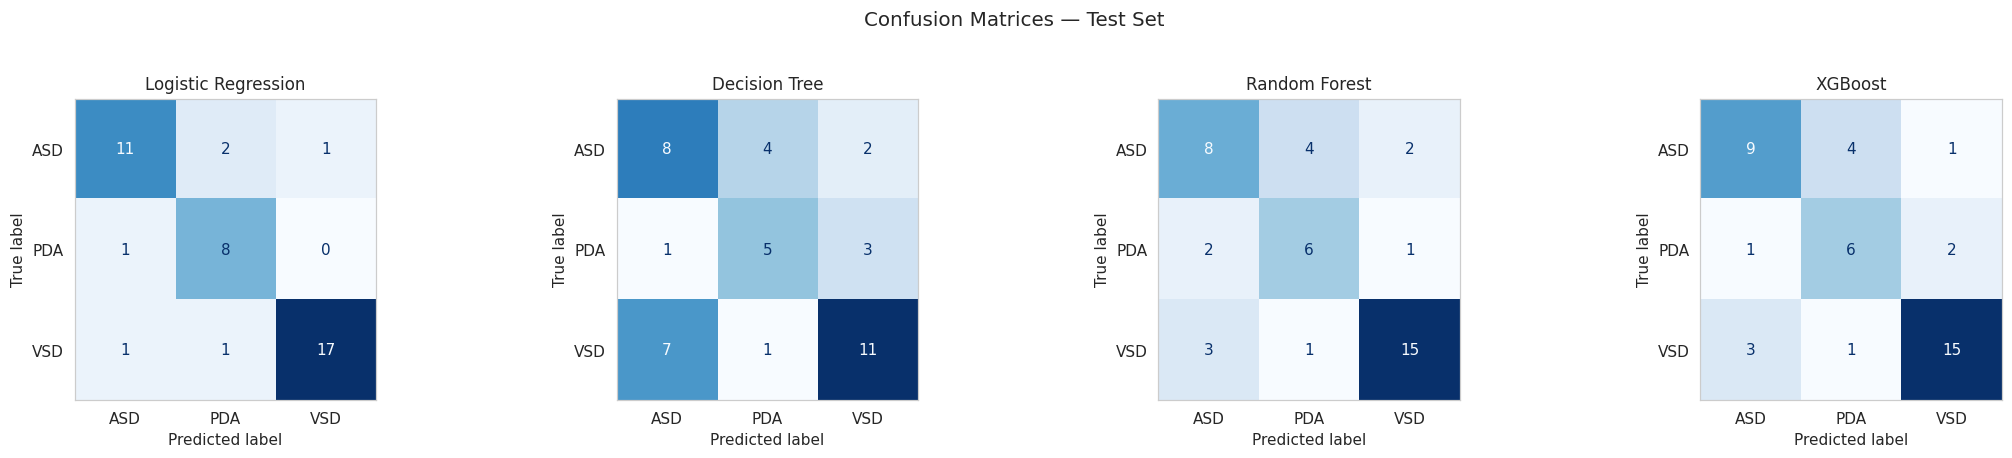

In [25]:
all_results = [lr_res, dt_res, rf_res, xgb_res]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, res in zip(axes, all_results):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=class_names,
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(res['Model'], fontsize=11)
    ax.grid(False)
plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 15. Feature Importance

Feature importance (mean decrease in impurity) identifies which clinical variables drive model decisions. Features ranked highly by *both* tree models are the most reliable predictors.


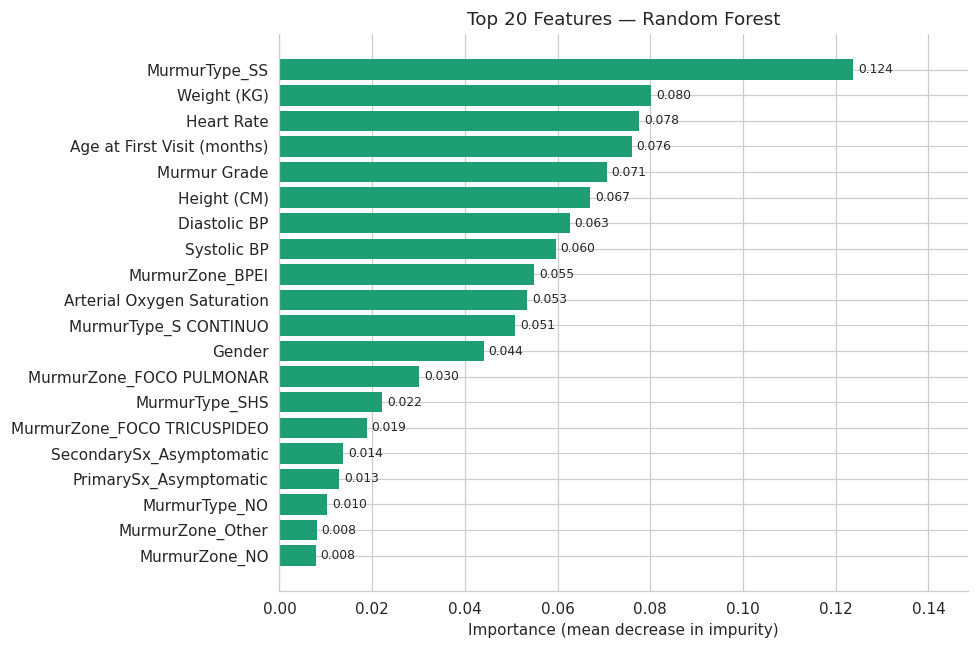

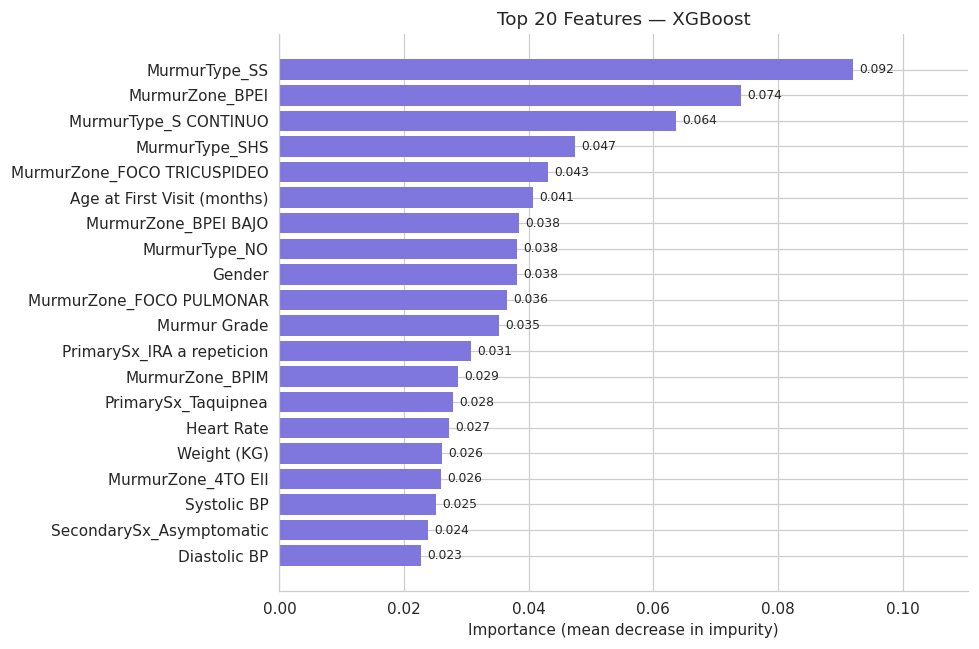

In [26]:
feature_names = X_train_enc.columns.tolist()
TOP_N = 20

def plot_importance(model, feat_names, title, color):
    imp = pd.Series(model.feature_importances_, index=feat_names)
    top = imp.nlargest(TOP_N).sort_values()
    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(top.index, top.values, color=color, edgecolor='none')
    for bar, val in zip(bars, top.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left', fontsize=8)
    ax.set_xlabel("Importance (mean decrease in impurity)")
    ax.set_title(f"Top {TOP_N} Features — {title}", fontsize=12)
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlim(0, top.values.max() * 1.2)
    plt.tight_layout()
    plt.show()

plot_importance(rf_model,  feature_names, "Random Forest", "#1D9E75")
plot_importance(xgb_model, feature_names, "XGBoost",       "#7F77DD")

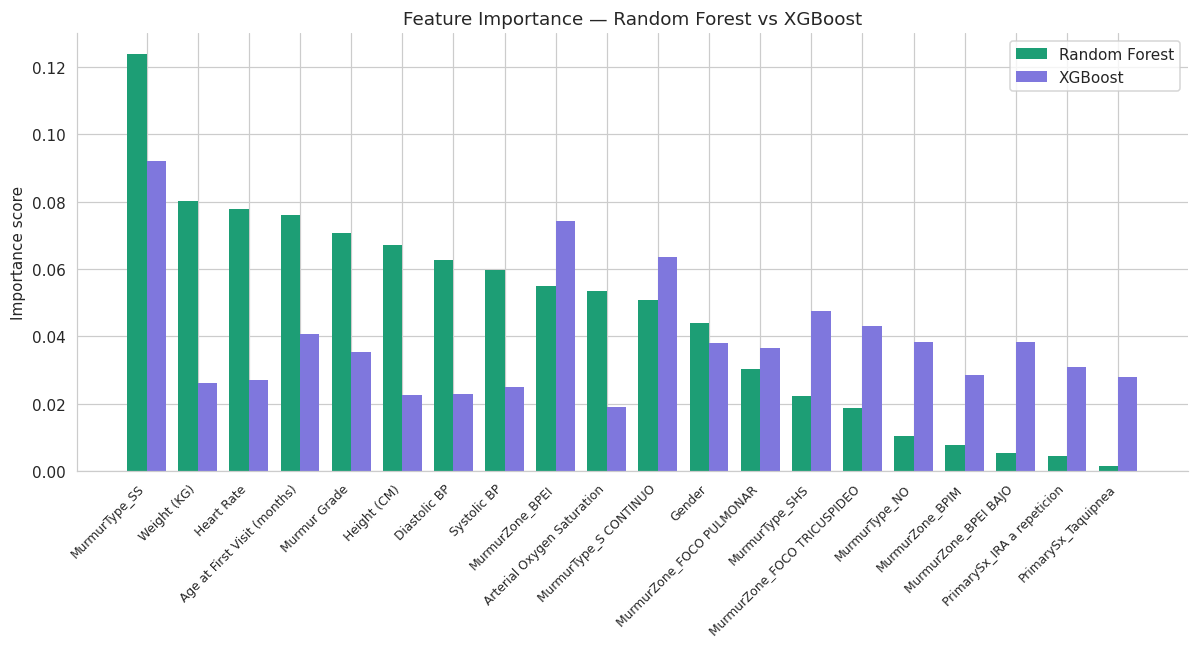

In [27]:
# ── Side-by-side comparison ───────────────────────────────────────────────
rf_imp  = pd.Series(rf_model.feature_importances_,  index=feature_names)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names)
top_union = list(set(rf_imp.nlargest(15).index) | set(xgb_imp.nlargest(15).index))

comparison = pd.DataFrame({
    'Random Forest': rf_imp[top_union],
    'XGBoost':       xgb_imp[top_union]
}).sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(comparison))
w = 0.38
ax.bar([i - w/2 for i in x], comparison['Random Forest'],
       width=w, label='Random Forest', color='#1D9E75', edgecolor='none')
ax.bar([i + w/2 for i in x], comparison['XGBoost'],
       width=w, label='XGBoost',       color='#7F77DD', edgecolor='none')
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Importance score")
ax.set_title("Feature Importance — Random Forest vs XGBoost", fontsize=12)
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## 16. ROC Curves (One-vs-Rest)

ROC curves show the trade-off between sensitivity and specificity for each class. A macro-average AUC above 0.85 is considered strong for a three-class clinical classifier.


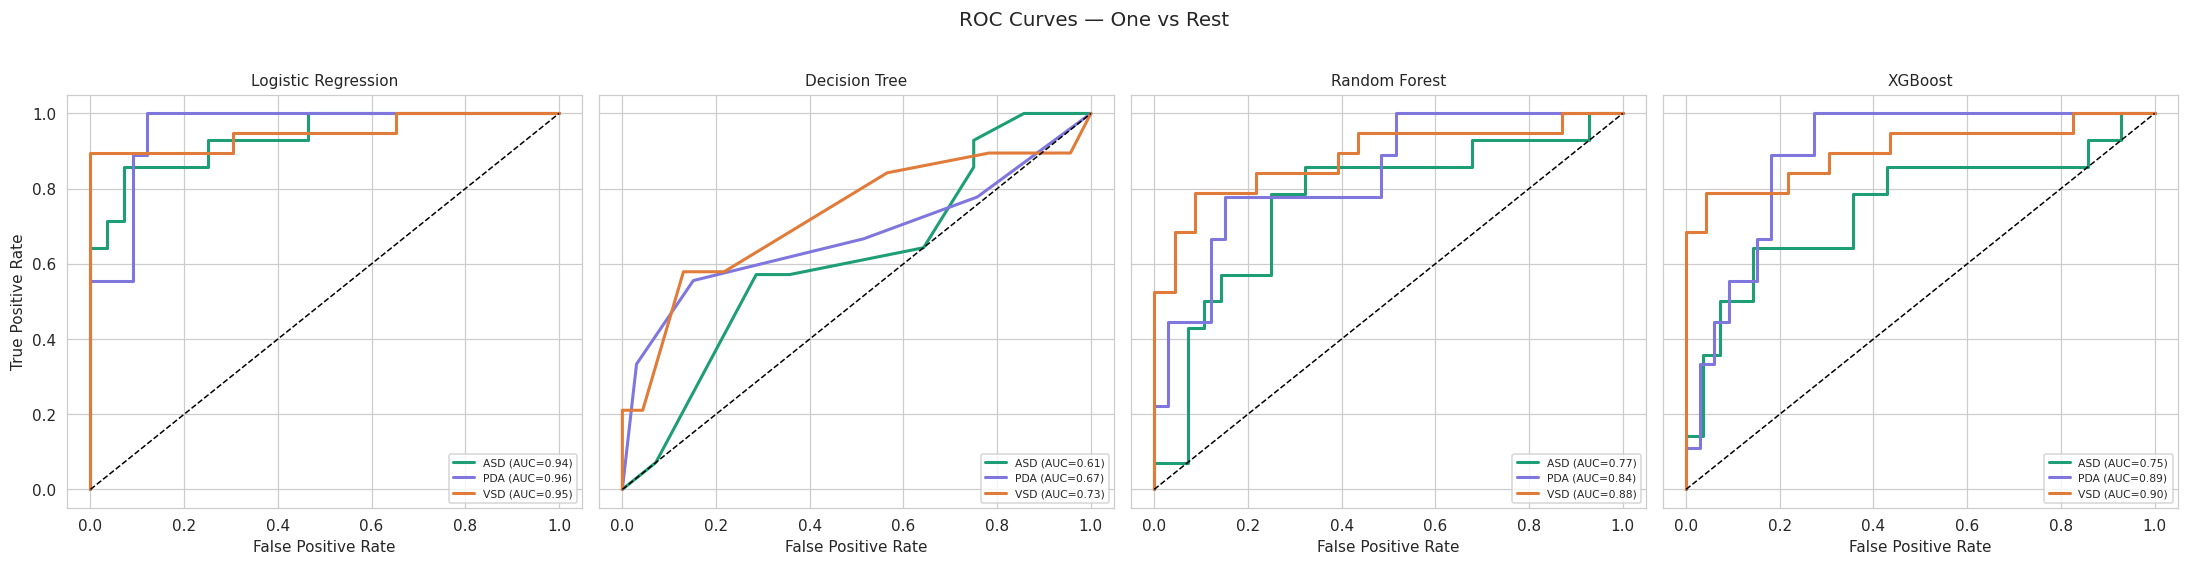

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['#1D9E75','#7F77DD','#E07B39']

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, res in zip(axes, all_results):
    for i, (cls, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], res['y_proba'][:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={roc_auc_val:.2f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(res['Model'], fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
axes[0].set_ylabel('True Positive Rate')
plt.suptitle("ROC Curves — One vs Rest", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 17. Decision Tree Visualisation

The Decision Tree provides an interpretable rule-set suitable for a clinical appendix.


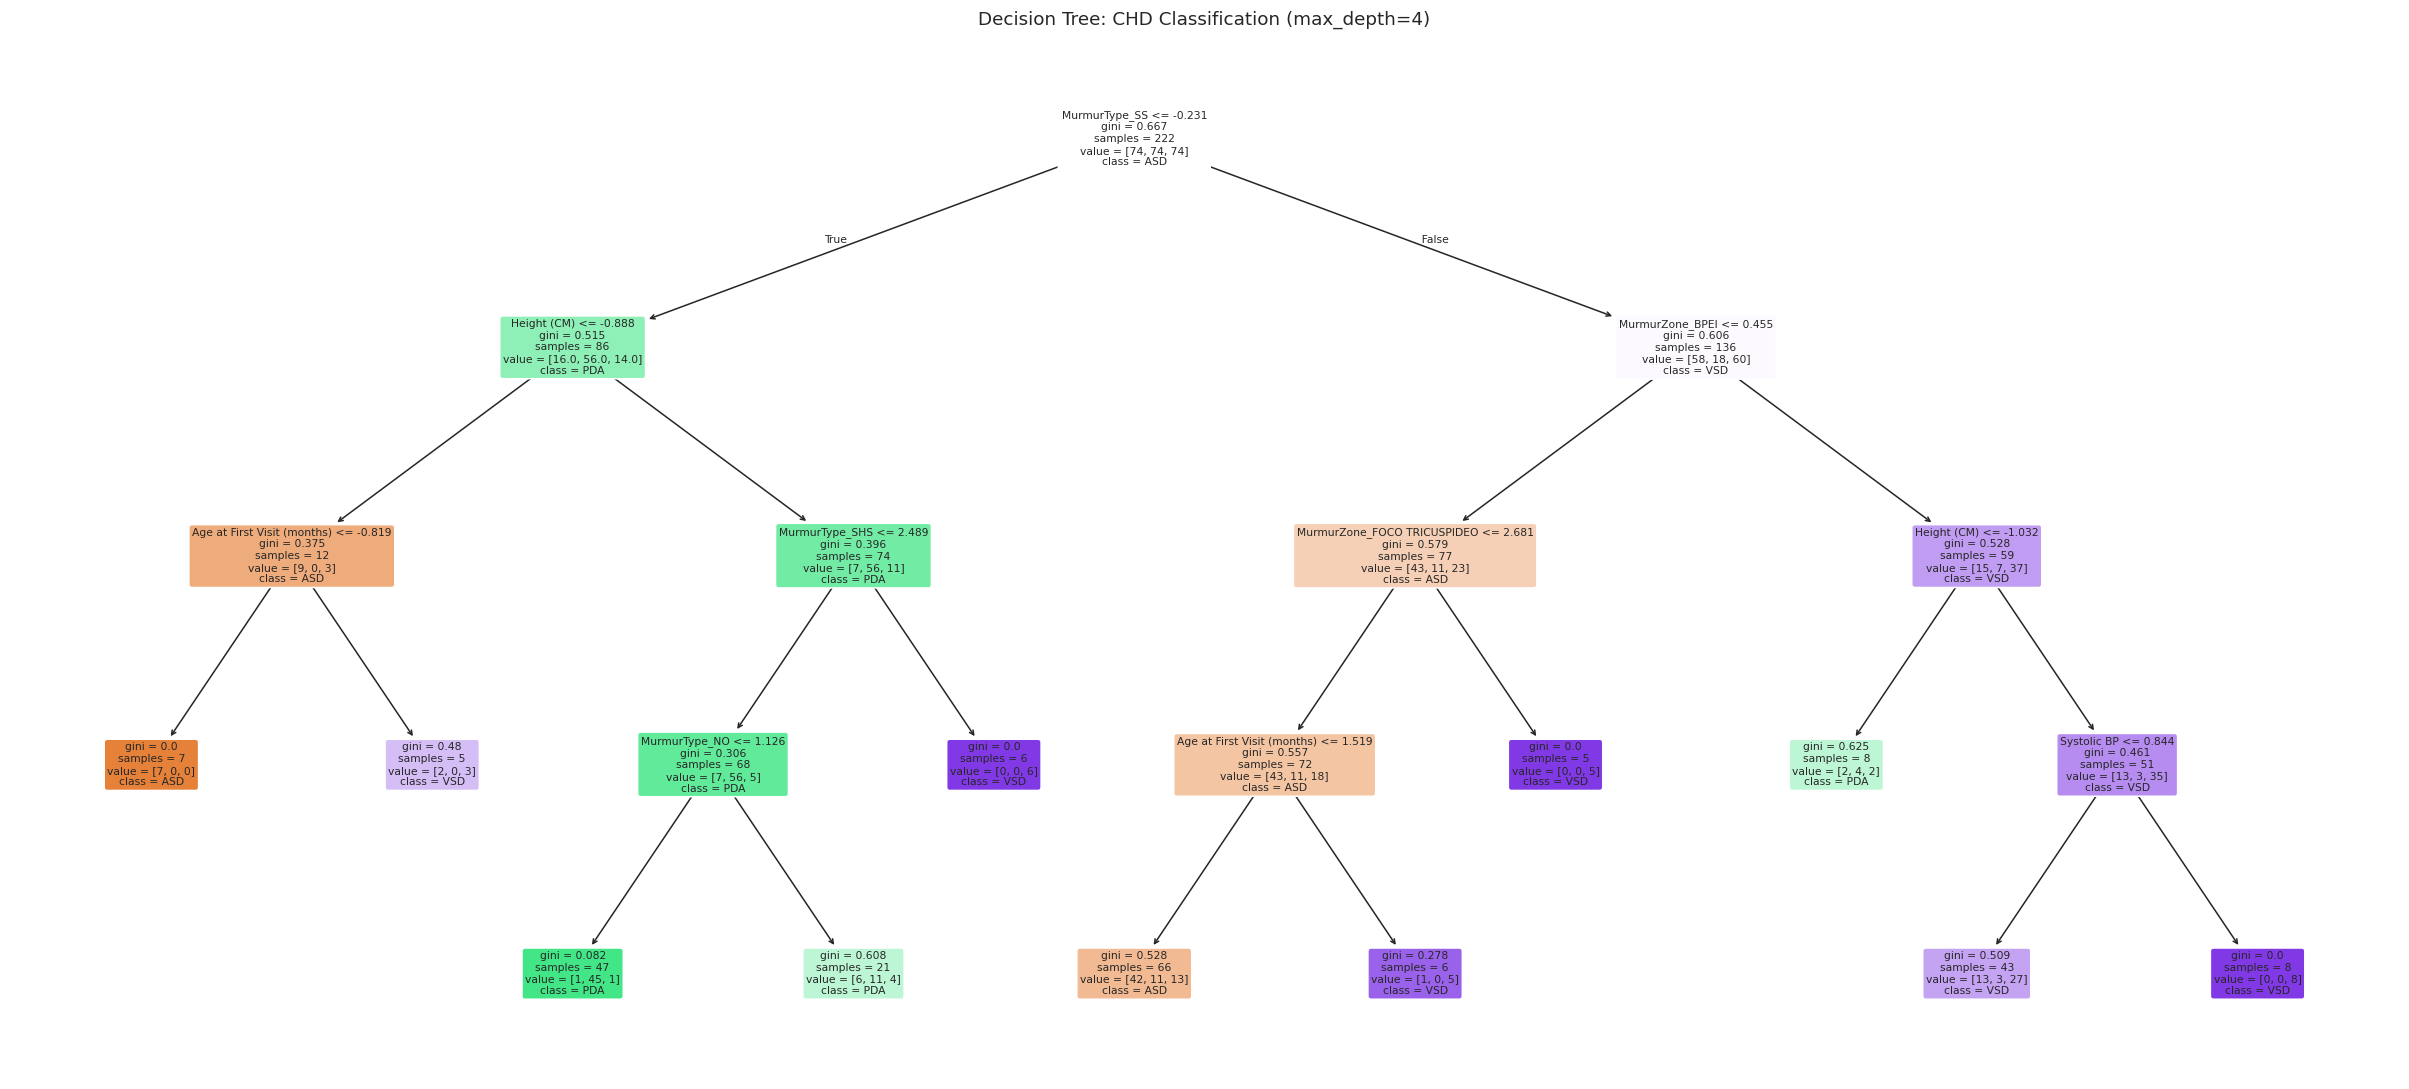

Decision tree rules saved to decision_tree_rules.txt


In [29]:
plt.figure(figsize=(22, 10))
plot_tree(dt_model, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7)
plt.title("Decision Tree: CHD Classification (max_depth=4)", fontsize=12)
plt.tight_layout()
plt.show()

rules = export_text(dt_model, feature_names=feature_names)
with open("decision_tree_rules.txt", "w") as f:
    f.write(rules)
print("Decision tree rules saved to decision_tree_rules.txt")


## 18. Model Comparison Summary

The table below summarises all metrics for the four classifiers. All scores are on the held-out test set; CV F1 is 5-fold stratified cross-validation on the balanced training set.


In [30]:
summary_rows = []
for res in all_results:
    summary_rows.append({
        'Model':              res['Model'],
        'Accuracy':           res['Accuracy'],
        'Precision (macro)':  res['Precision (macro)'],
        'Recall (macro)':     res['Recall (macro)'],
        'F1 (macro)':         res['F1 (macro)'],
        'ROC-AUC (macro)':    res['ROC-AUC'],
        'CV F1 mean':         res['CV F1 mean'],
        'CV F1 std':          res['CV F1 std'],
    })

results_df = pd.DataFrame(summary_rows).round(3)
results_df.to_csv("model_comparison_results.csv", index=False)
print(results_df.to_string(index=False))


              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  ROC-AUC (macro)  CV F1 mean  CV F1 std
Logistic Regression     0.857              0.839           0.856       0.845            0.947       0.674      0.033
      Decision Tree     0.571              0.562           0.569       0.563            0.670       0.572      0.035
      Random Forest     0.690              0.665           0.676       0.668            0.829       0.698      0.049
            XGBoost     0.714              0.690           0.700       0.692            0.848       0.691      0.060


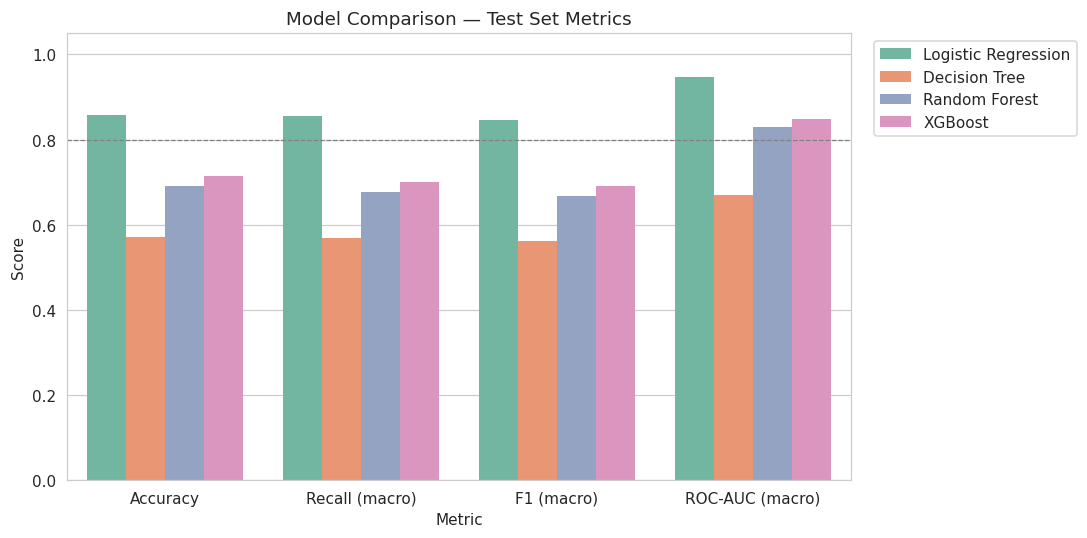

In [31]:
# ── Bar chart comparison ──────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Recall (macro)', 'F1 (macro)', 'ROC-AUC (macro)']
melted = results_df.melt(id_vars='Model', value_vars=metrics_to_plot,
                          var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 5))
sns.barplot(data=melted, x='Metric', y='Score', hue='Model',
            palette='Set2', edgecolor='none')
plt.ylim(0, 1.05)
plt.title("Model Comparison — Test Set Metrics", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhline(0.8, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


Logistic Regression
ASD


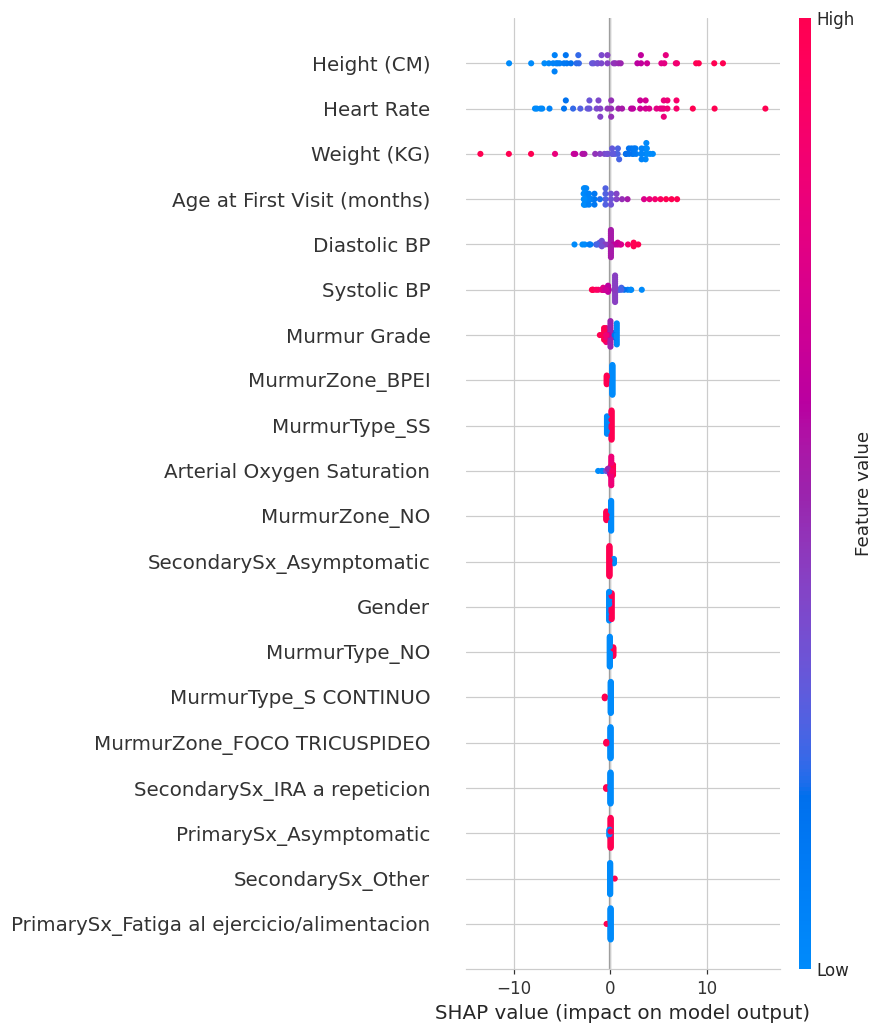

PDA


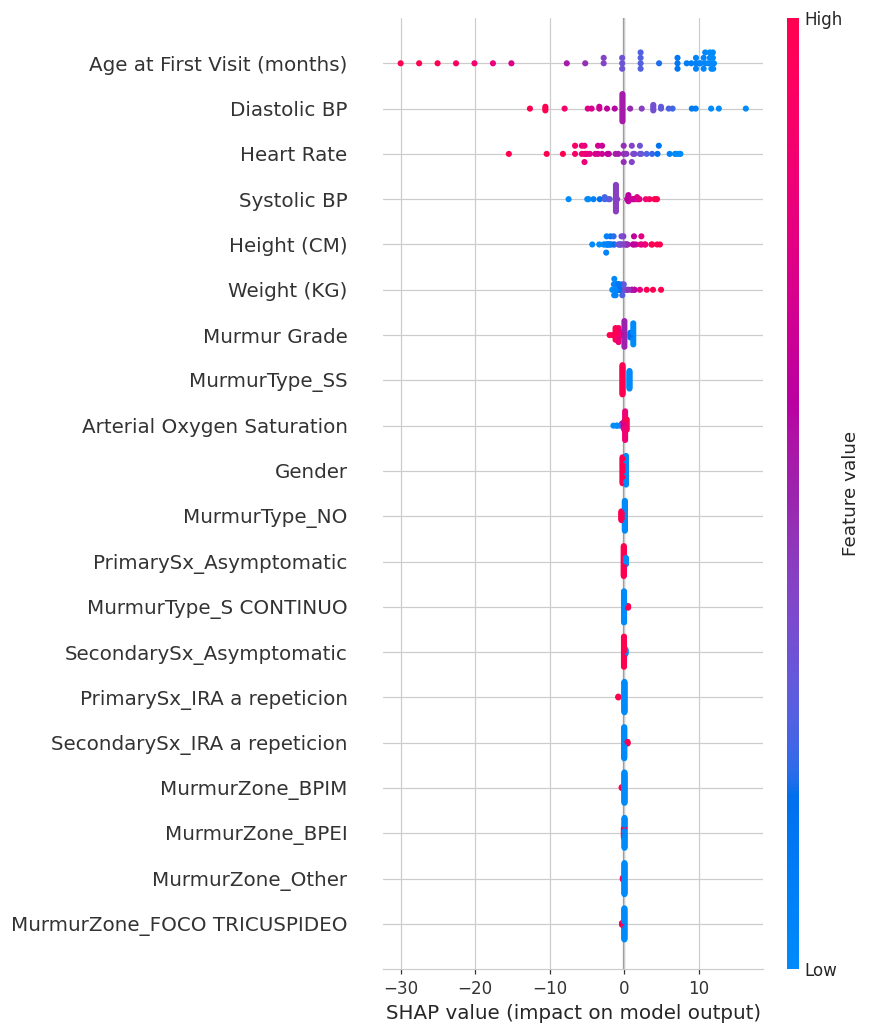

VSD


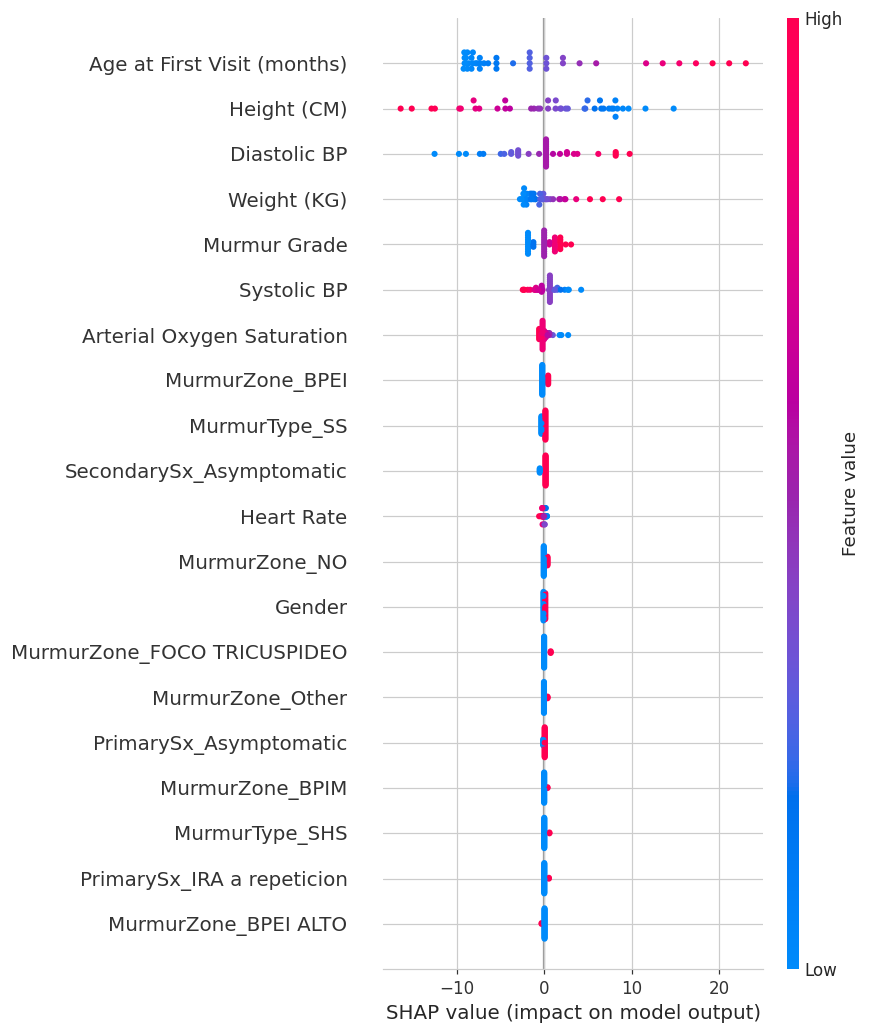

Decision Tree
ASD


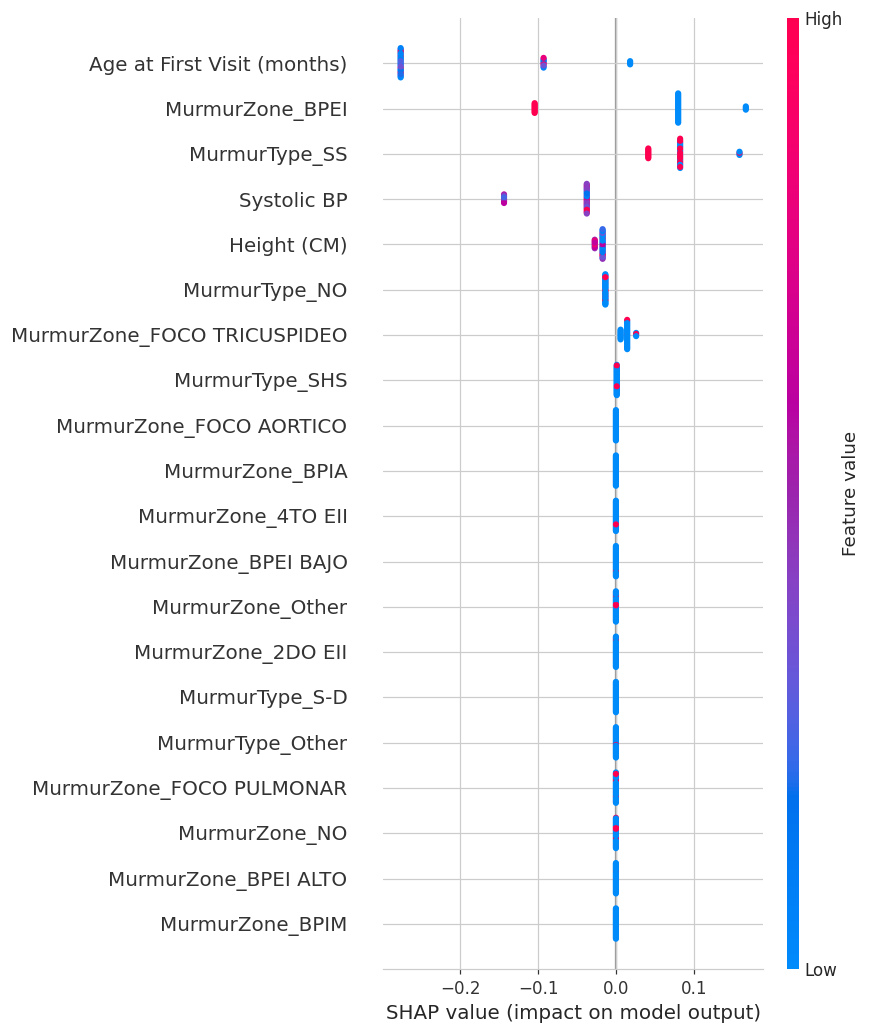

PDA


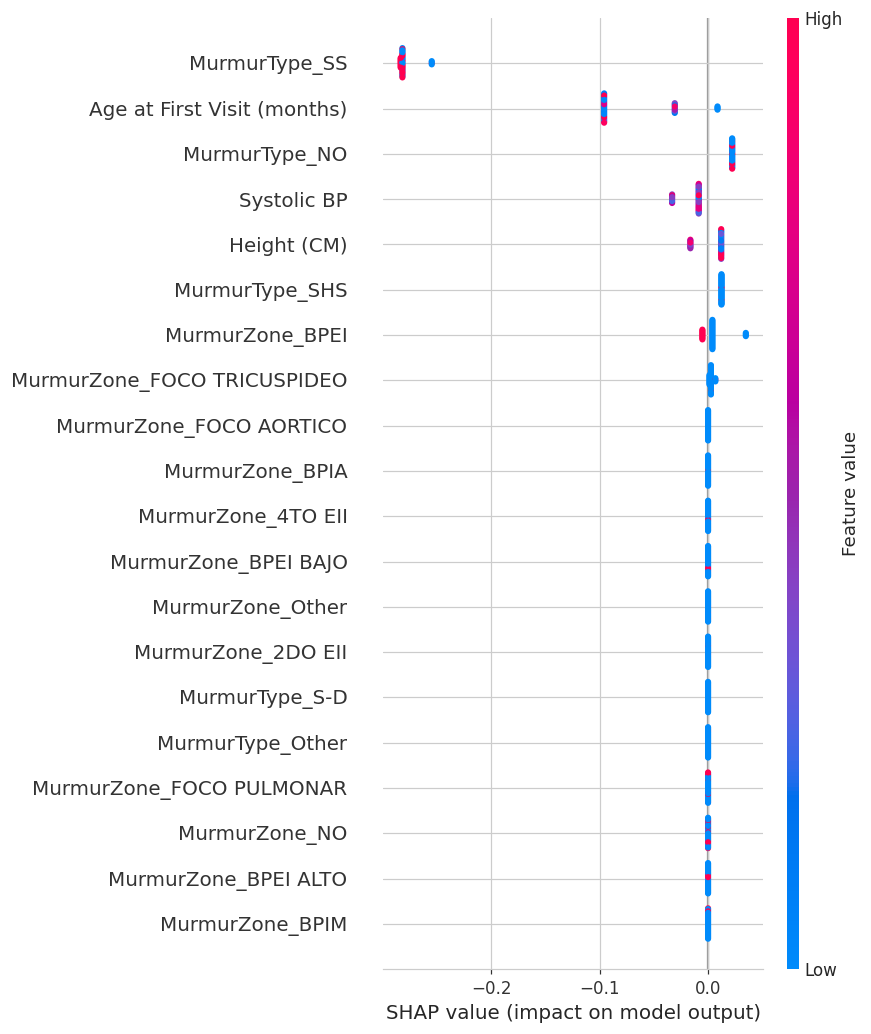

VSD


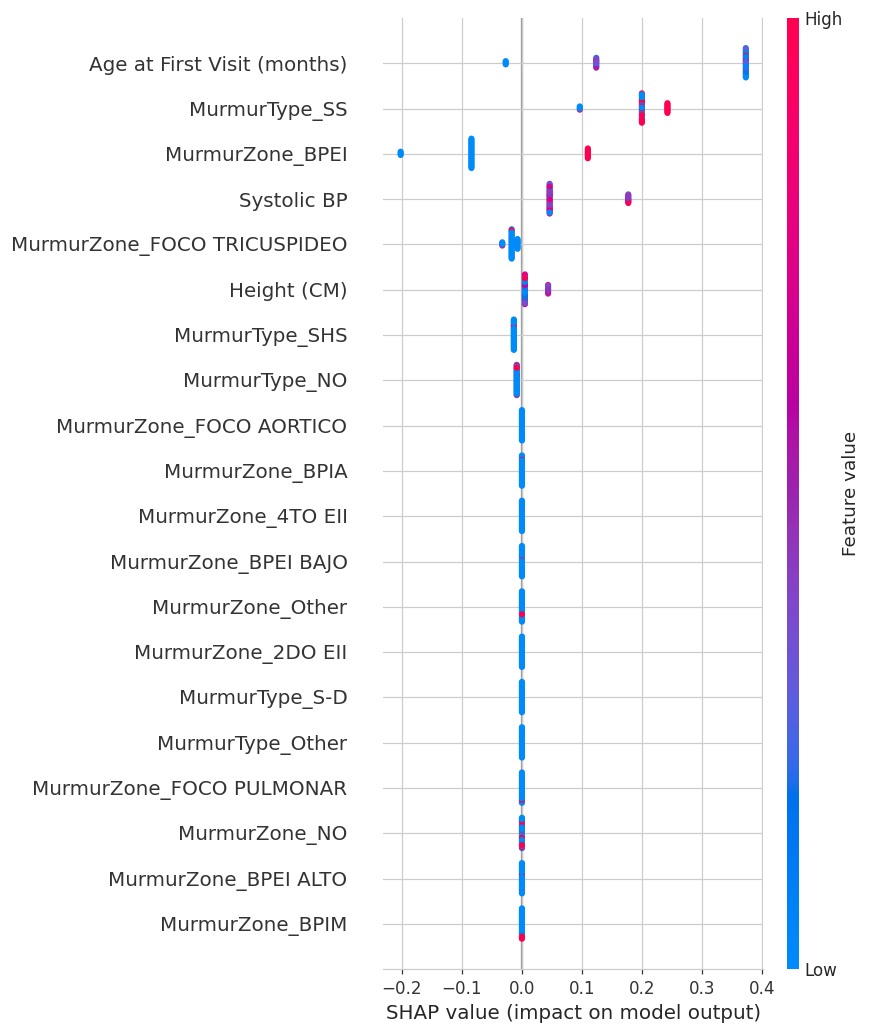

Random Forest
ASD


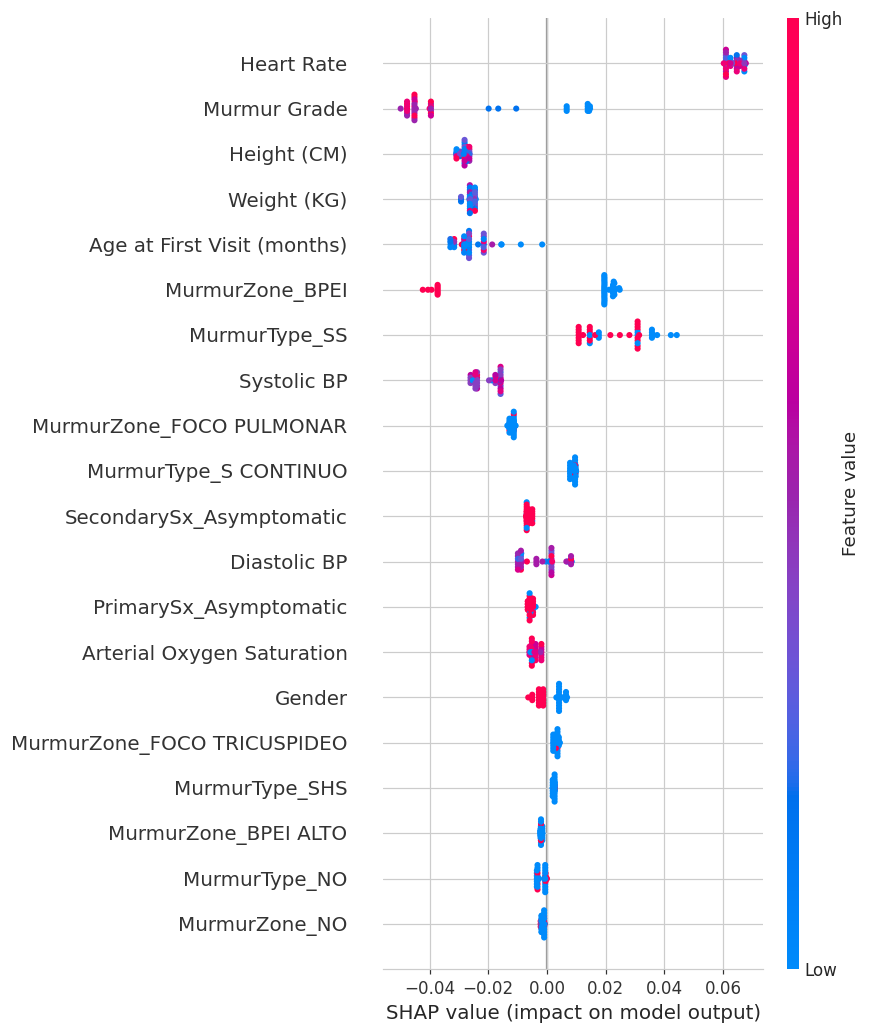

PDA


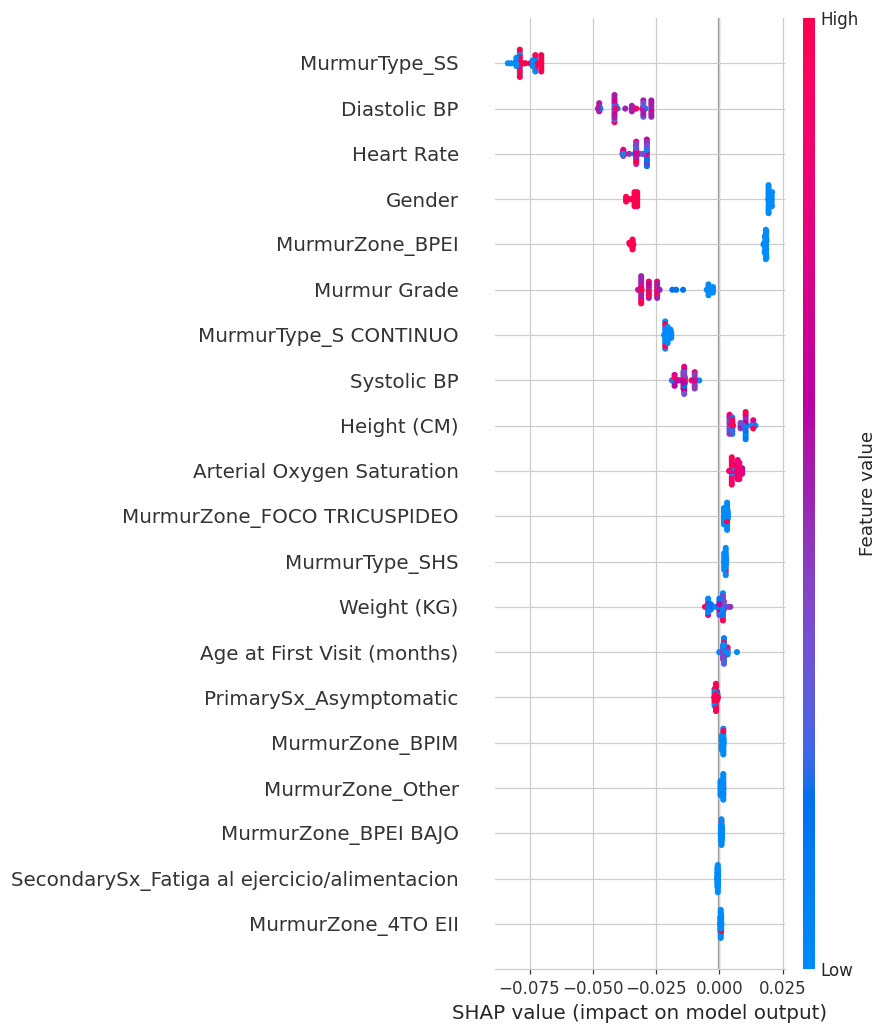

VSD


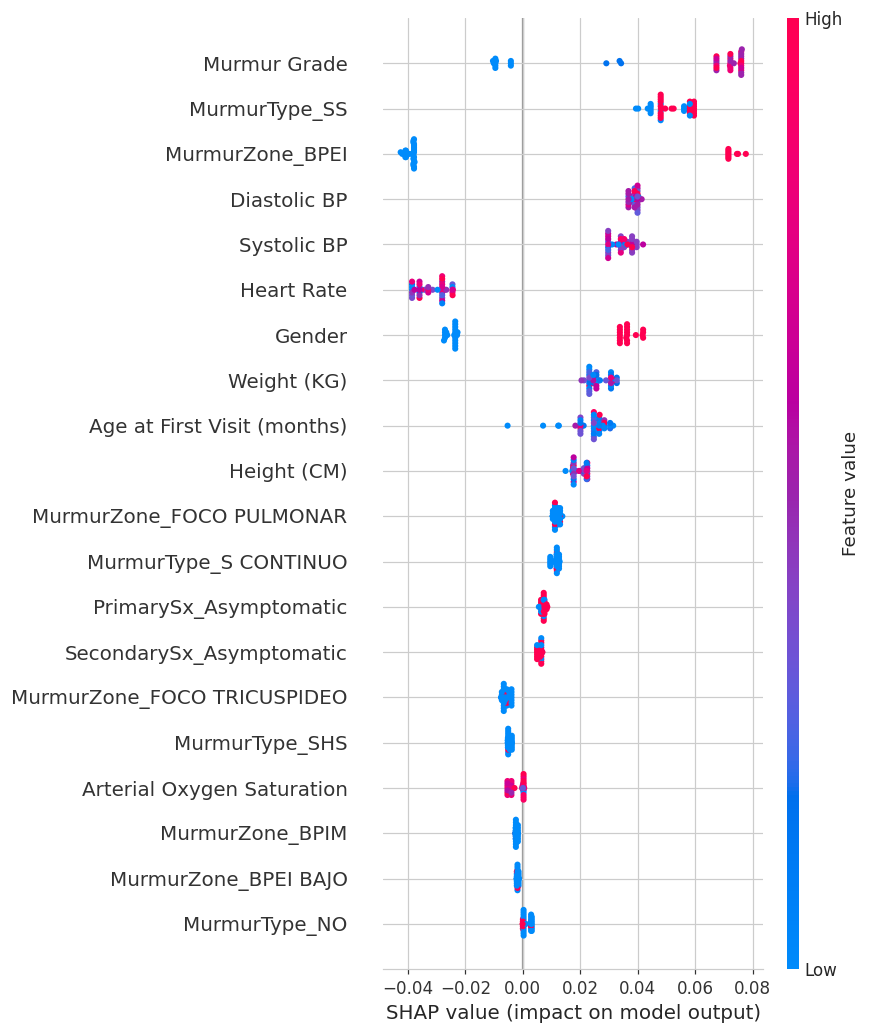

XGBoost
ASD


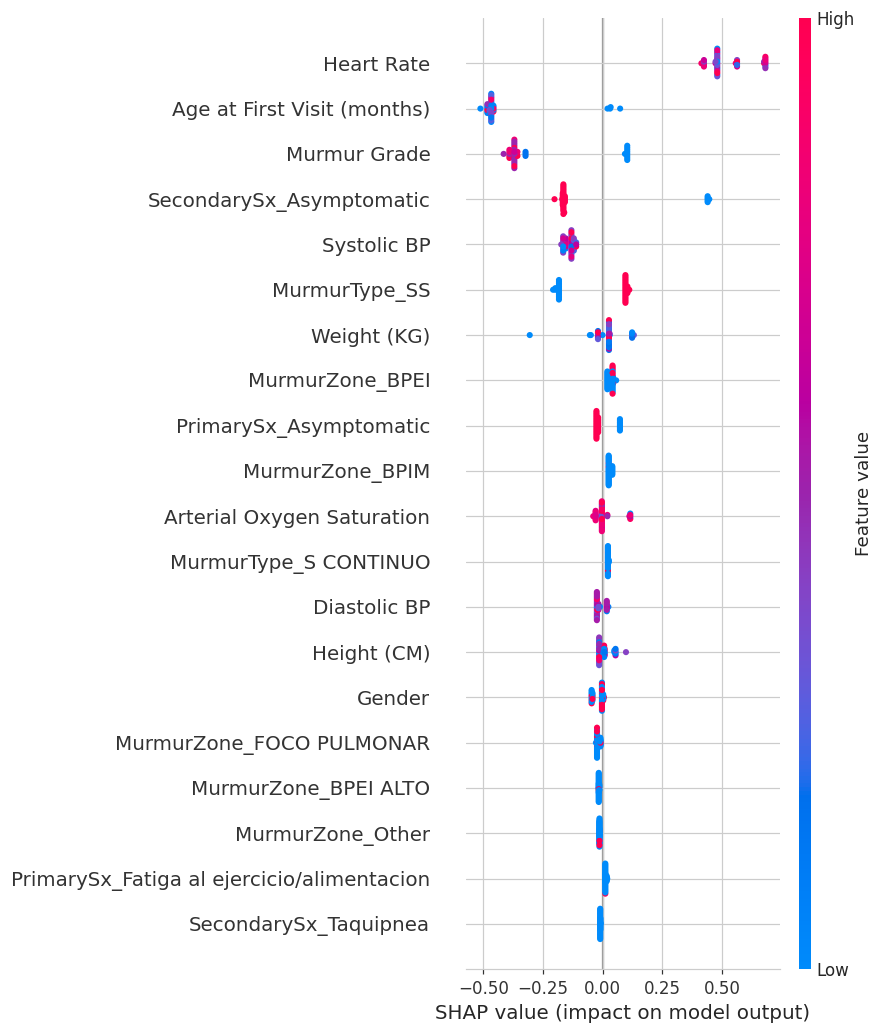

PDA


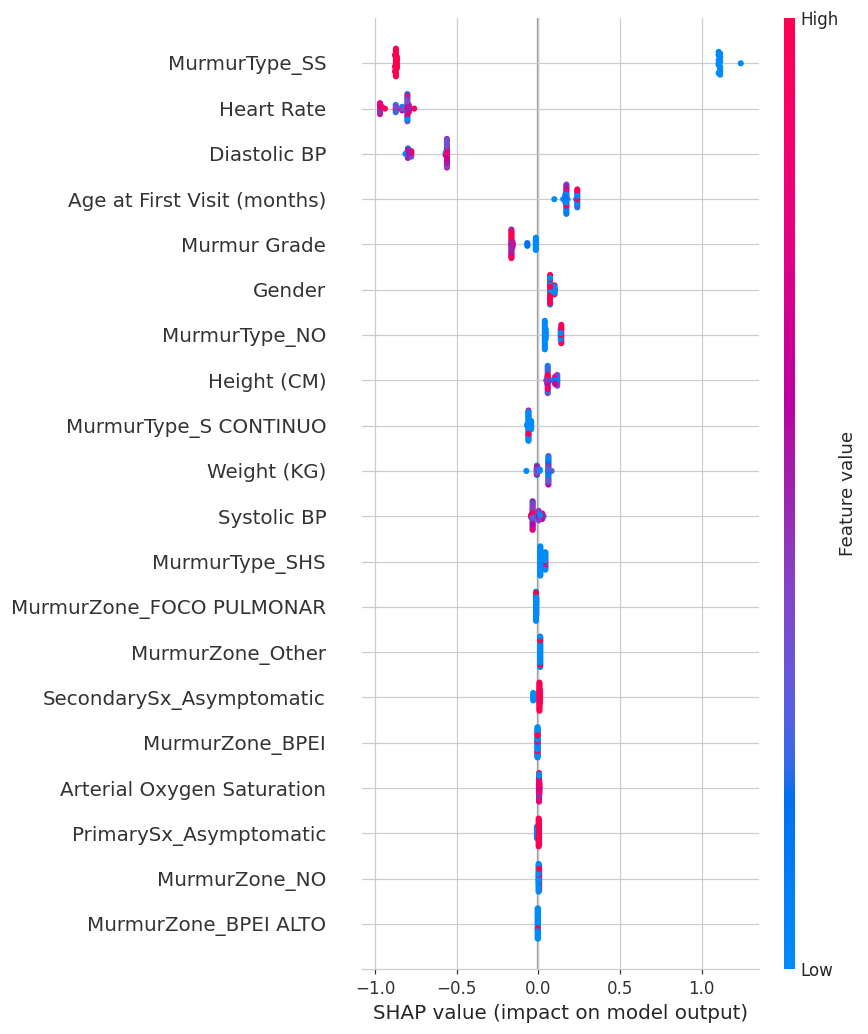

VSD


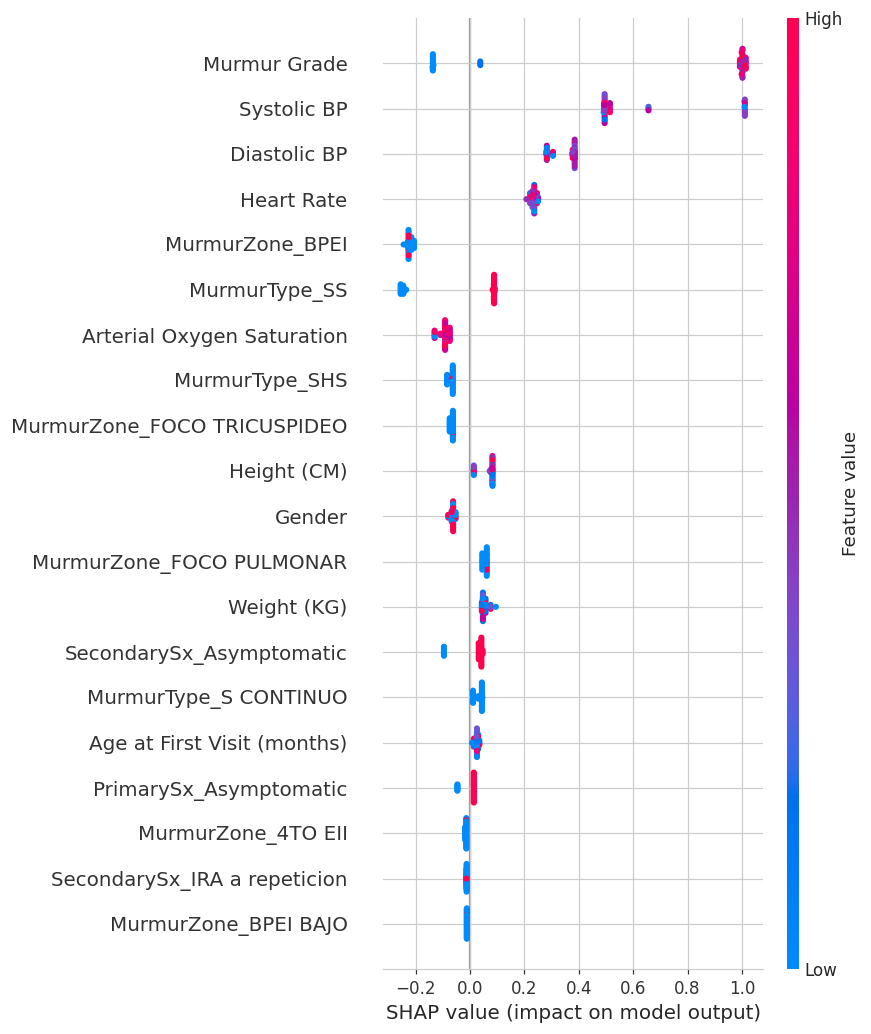

In [32]:
models = {
    "Logistic Regression": lr_res["fitted_model"],
    "Decision Tree": dt_res["fitted_model"],
    "Random Forest": rf_res["fitted_model"],
    "XGBoost": xgb_res["fitted_model"]
}

for model_name, model in models.items():

    print("="*70)
    print(model_name)
    print("="*70)

    # Tree Models
    if model_name in ["Decision Tree", "Random Forest", "XGBoost"]:

        explainer = shap.TreeExplainer(model)

        shap_values = explainer.shap_values(X_test_enc)
        print("="*70)
        print('ASD')
        print("="*70)
        class_id = 0
        shap.summary_plot(shap_values[:, :, class_id], X_test_enc)
        print("="*70)
        print('PDA')
        print("="*70)
        class_id = 1
        shap.summary_plot(shap_values[:, :, class_id], X_test_enc)
        print("="*70)
        print('VSD')
        print("="*70)
        class_id = 2
        shap.summary_plot(shap_values[:, :, class_id], X_test_enc)

    # Logistic Regression

    else:

        explainer = shap.LinearExplainer(
            model,
            X_train_enc
        )

        shap_values = explainer.shap_values(X_test_enc)
        print("="*70)
        print('ASD')
        print("="*70)
        class_id = 0
        shap.summary_plot(shap_values[:, :, class_id], X_test_enc)
        print("="*70)
        print('PDA')
        print("="*70)
        class_id = 1
        shap.summary_plot(shap_values[:, :, class_id], X_test_enc)
        print("="*70)
        print('VSD')
        print("="*70)
        class_id = 2
        shap.summary_plot(shap_values[:, :, class_id], X_test_enc)

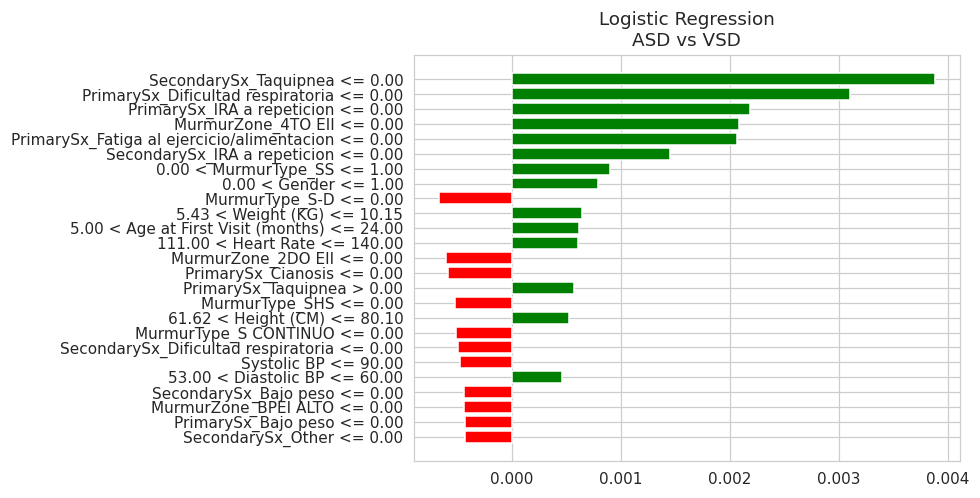

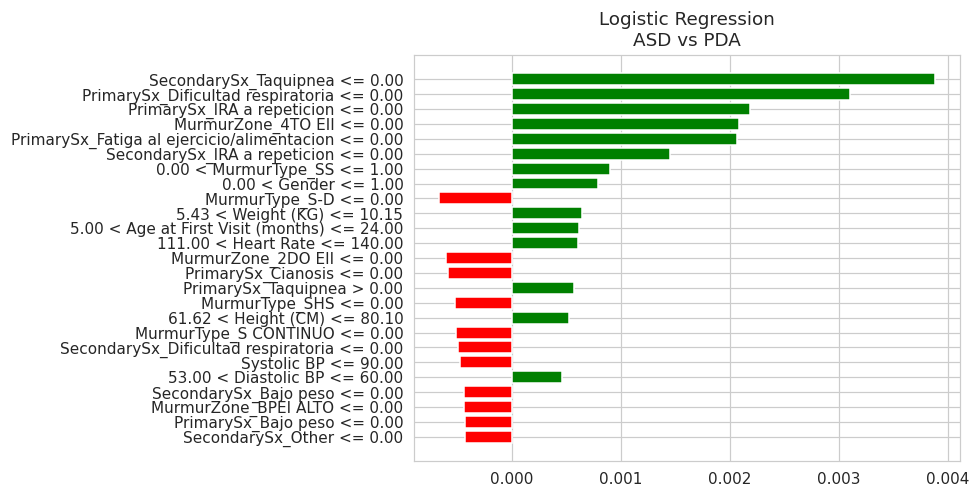

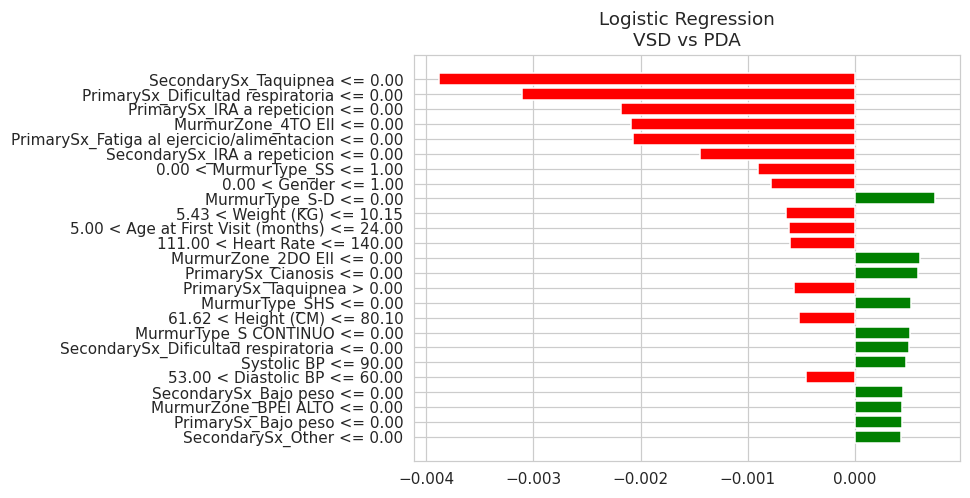

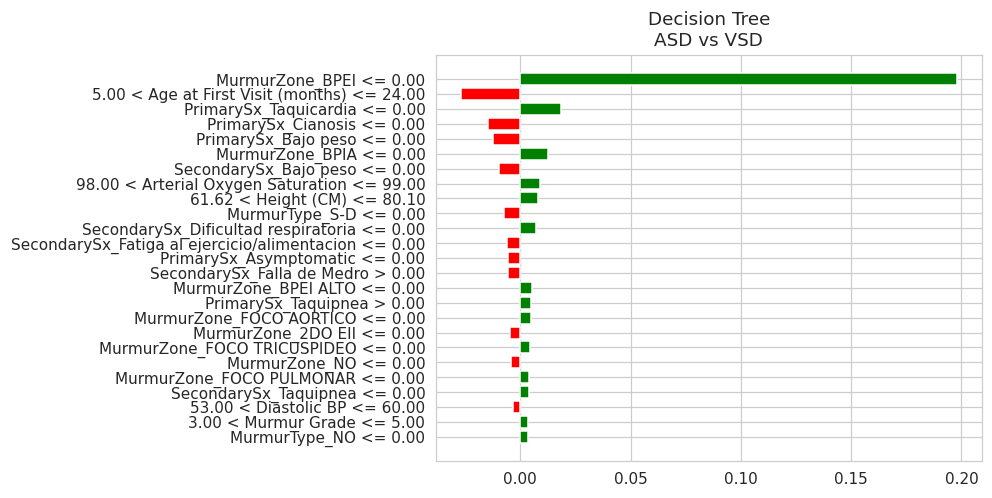

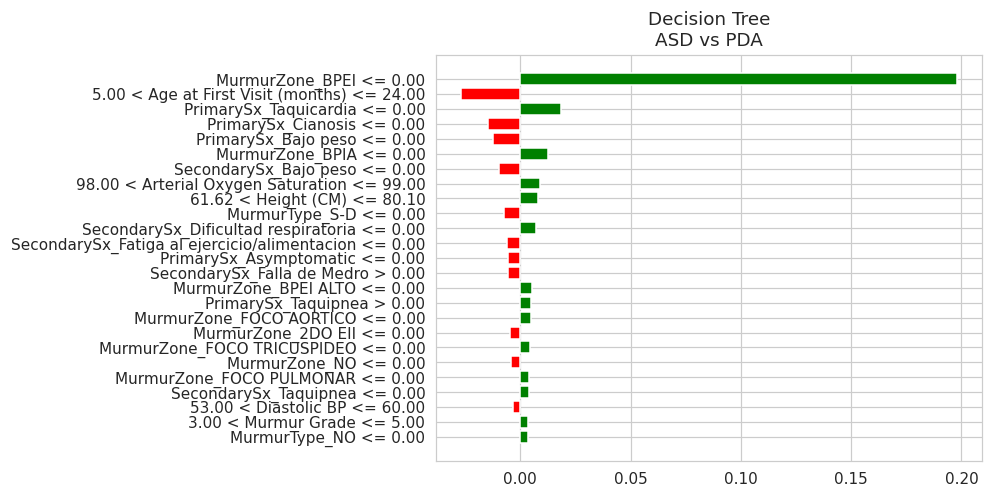

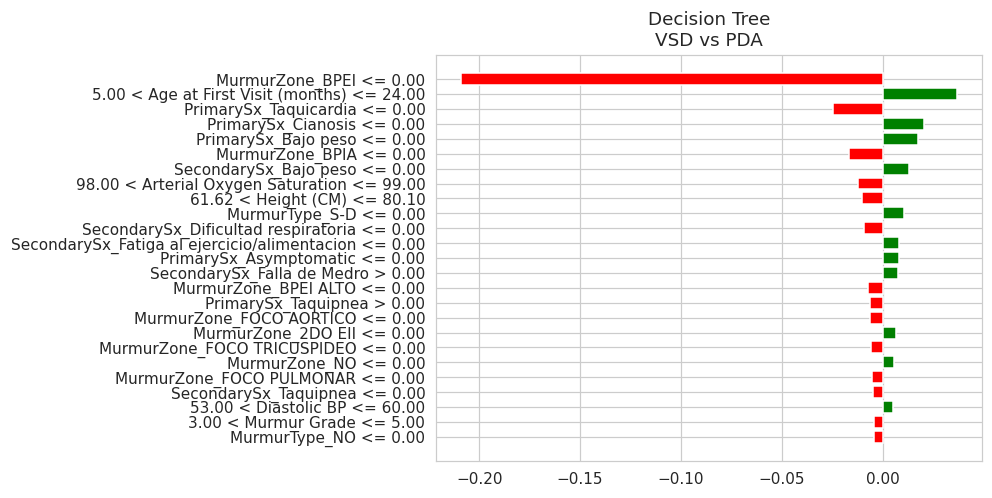

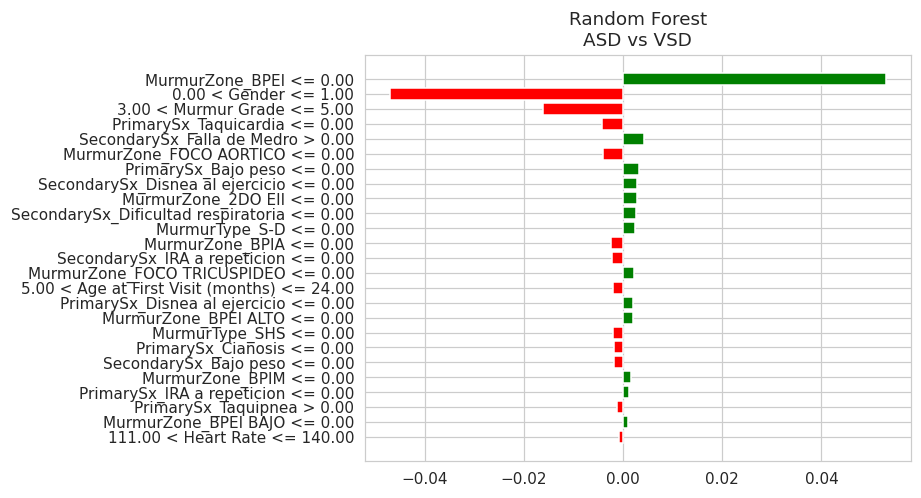

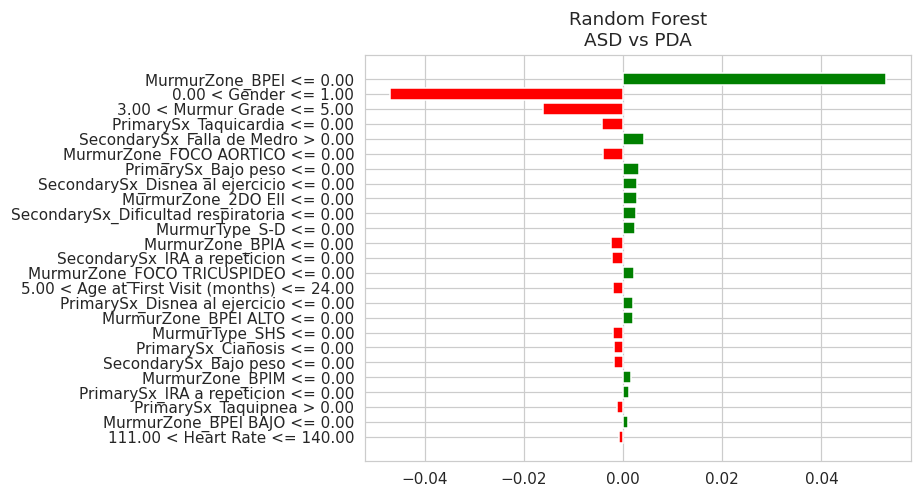

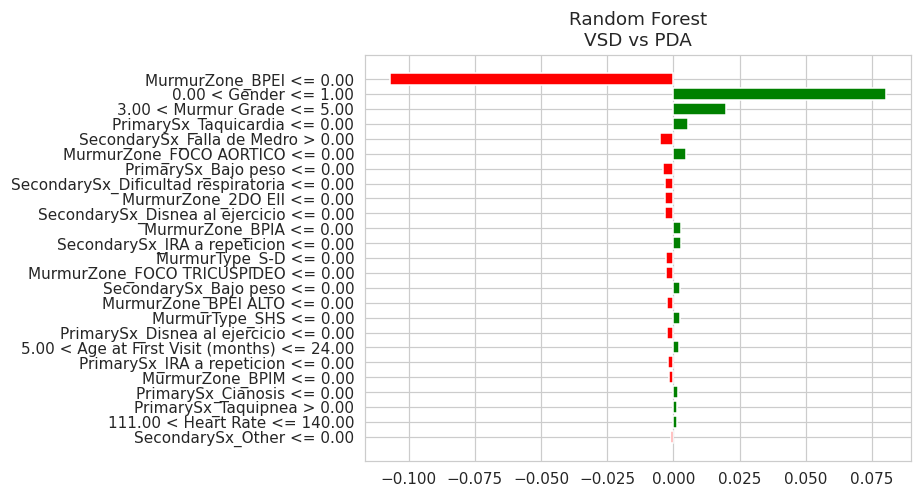

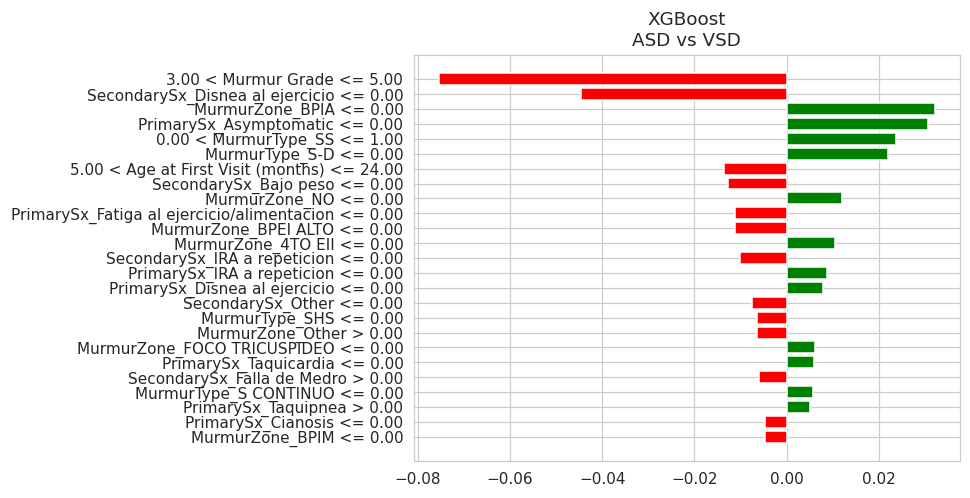

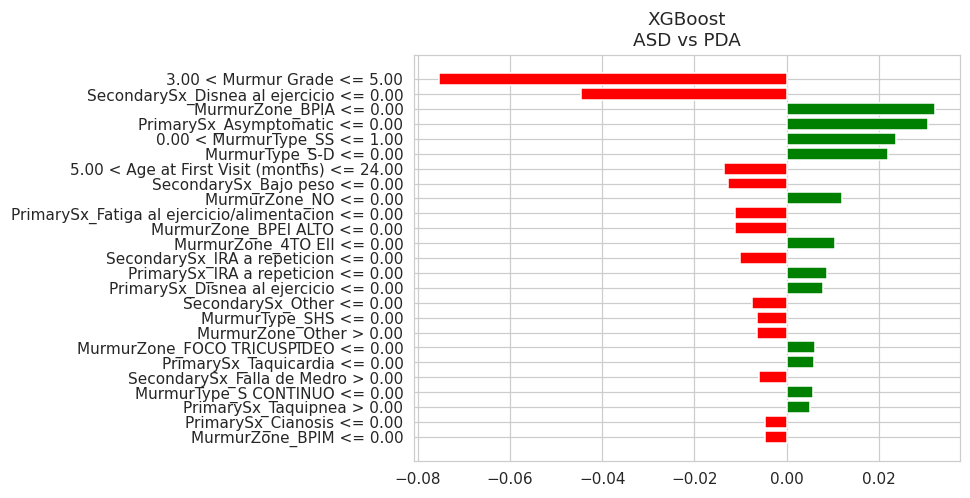

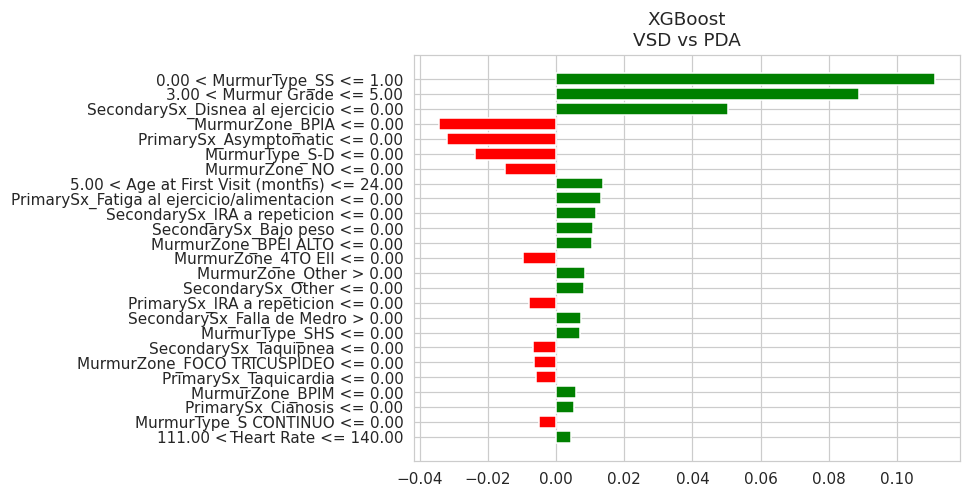

In [33]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_enc),
    feature_names=X_train_enc.columns.tolist(),
    class_names=le_target.classes_.tolist(),
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

models = {
    "Logistic Regression": lr_res["fitted_model"],
    "Decision Tree": dt_res["fitted_model"],
    "Random Forest": rf_res["fitted_model"],
    "XGBoost": xgb_res["fitted_model"]
}

sample = 0      # Change patient index if desired

pairs = [
    ("ASD", "VSD"),
    ("ASD", "PDA"),
    ("VSD", "PDA")
]

for model_name, model in models.items():

    explanation = lime_explainer.explain_instance(
        data_row=X_test_enc.iloc[sample].values,
        predict_fn=model.predict_proba,
        num_features=25,
        top_labels=3
    )

    probs = model.predict_proba(X_test_enc.iloc[[sample]])[0]

    # Create one figure for every pair
    for disease1, disease2 in pairs:

        label1 = np.where(le_target.classes_ == disease1)[0][0]
        label2 = np.where(le_target.classes_ == disease2)[0][0]

        fig = explanation.as_pyplot_figure(label=label1)

        plt.title(f"{model_name}\n{disease1} vs {disease2}")

        plt.show()

        # explanation.save_to_file(
        #     f"{model_name.replace(' ','_')}_{disease1}_vs_{disease2}.html"
        # )

## 19. Save artifacts for django webapp


In [34]:
# ============================================================
# EXPORT LOGISTIC REGRESSION ARTIFACTS FOR THE DJANGO APP
# ============================================================
import json
import os
import joblib

OUT_DIR = "django_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Sanity check: make sure the expected variables exist ──
required = ['df', 'X_train_raw', 'X_test_raw', 'X_train_enc', 'le_target', 'lr_res']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. Run cells 1–38 in order first.")

# ── 1. The fitted LR model + the SAME StandardScaler used to fit it ──
# `evaluate(..., scale=True)` fit a StandardScaler internally on X_train_bal
# and returned it inside the result dict — that's the one that actually
# produced the numbers lr_model was trained on, so it's the one we must ship.
fitted_lr_model = lr_res['fitted_model']
fitted_scaler   = lr_res['scaler']

# Quick shape sanity check before saving anything
assert fitted_lr_model.coef_.shape[1] == len(X_train_enc.columns), \
    "Model's feature count doesn't match X_train_enc — did you rerun encode_split with different settings?"

joblib.dump(fitted_lr_model, f'{OUT_DIR}/lr_model.joblib')
joblib.dump(fitted_scaler,   f'{OUT_DIR}/scaler.joblib')
joblib.dump(le_target,       f'{OUT_DIR}/label_encoder.joblib')

# ── 2. Re-derive the categorical maps `encode_split` used ──
# (They were local variables inside that function, so we recompute them here
#  from the SAME X_train_raw split. value_counts() is deterministic, so this
#  reproduces the identical categories/order the model was actually fit on.)
gender_map  = {'FEMENINO': 0, 'MASCULINO': 1}
grade_order = ['NO', 'G1', 'G1-2', 'G2', 'G2-3', 'G3', 'G4', 'G4-5', 'G5']
grade_map   = {g: i for i, g in enumerate(grade_order)}

primary_symptom_categories   = X_train_raw['Primary Symptom'].value_counts().index.tolist()
secondary_symptom_categories = X_train_raw['Secondary Symptoms'].value_counts().nlargest(8).index.tolist()
murmur_type_categories       = X_train_raw['Murmur Type'].value_counts().index.tolist()
murmur_zone_categories       = X_train_raw['Murmur Zone'].value_counts().nlargest(11).index.tolist()

# ── 3. Imputation values (median/mean/mode) ──
# `df` here has ALREADY been imputed (your cell 25 ran earlier). Recomputing
# median/mean/mode on already-imputed data returns the SAME numbers — filling
# NaNs with a column's own median/mean/mode never moves that median/mean/mode —
# so this safely reconstructs what was actually used, without touching your code.
impute_values = {}
for col in ['Age at First Visit (months)', 'Heart Rate', 'Arterial Oxygen Saturation',
            'Systolic BP', 'Diastolic BP']:
    impute_values[col] = float(df[col].median())
for col in ['Weight (KG)', 'Height (CM)']:
    impute_values[col] = float(df[col].mean())
for col in ['Gender', 'Primary Symptom', 'Secondary Symptoms', 'Murmur Type', 'Murmur Grade', 'Murmur Zone']:
    impute_values[col] = df[col].mode()[0]

# ── 4. Full dropdown option lists (every value seen in your cleaned dataset) ──
categorical_options = {
    'Gender': ['FEMENINO', 'MASCULINO'],
    'Primary Symptom': sorted(df['Primary Symptom'].unique().tolist()),
    'Secondary Symptoms': sorted(df['Secondary Symptoms'].unique().tolist()),
    'Murmur Type': sorted(df['Murmur Type'].unique().tolist()),
    'Murmur Grade': grade_order,
    'Murmur Zone': sorted(df['Murmur Zone'].unique().tolist()),
}

# ── 5. Final config Django needs to encode a single form submission ──
encoding_config = {
    'gender_map': gender_map,
    'grade_order': grade_order,
    'grade_map': grade_map,
    'primary_symptom_categories': primary_symptom_categories,
    'secondary_symptom_categories': secondary_symptom_categories,
    'murmur_type_categories': murmur_type_categories,
    'murmur_zone_categories': murmur_zone_categories,
    'feature_order': X_train_enc.columns.tolist(),
    'class_names': le_target.classes_.tolist(),
    'impute_values': impute_values,
    'numeric_features': ['Weight (KG)', 'Height (CM)', 'Heart Rate',
                          'Arterial Oxygen Saturation', 'Age at First Visit (months)',
                          'Systolic BP', 'Diastolic BP'],
    'categorical_options': categorical_options,
}
with open(f'{OUT_DIR}/encoding_config.json', 'w') as f:
    json.dump(encoding_config, f, indent=2)

# ── 6. Metrics (optional — just for an "about the model" note) ──
metrics = {
    'accuracy': lr_res['Accuracy'],
    'precision_macro': lr_res['Precision (macro)'],
    'recall_macro': lr_res['Recall (macro)'],
    'f1_macro': lr_res['F1 (macro)'],
    'roc_auc_macro': lr_res['ROC-AUC'],
    'cv_f1_mean': lr_res['CV F1 mean'],
    'cv_f1_std': lr_res['CV F1 std'],
    'class_encoding': dict(zip(le_target.classes_.tolist(), range(len(le_target.classes_)))),
    'n_features': len(X_train_enc.columns),
    'n_train': int(X_train_raw.shape[0]),
    'n_test': int(X_test_raw.shape[0]),
}
with open(f'{OUT_DIR}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved files:", os.listdir(OUT_DIR))

import sklearn
print("\n Your Colab scikit-learn version:", sklearn.__version__)
print("    Make sure requirements.txt in the Django app pins this same version.")

# ── 7. Zip it and download ──
import shutil
shutil.make_archive('django_artifacts', 'zip', OUT_DIR)

# from google.colab import files
# files.download('django_artifacts.zip')

Saved files: ['encoding_config.json', 'label_encoder.joblib', 'metrics.json', 'lr_model.joblib', 'scaler.joblib']

 Your Colab scikit-learn version: 1.6.1
    Make sure requirements.txt in the Django app pins this same version.


'/content/django_artifacts.zip'